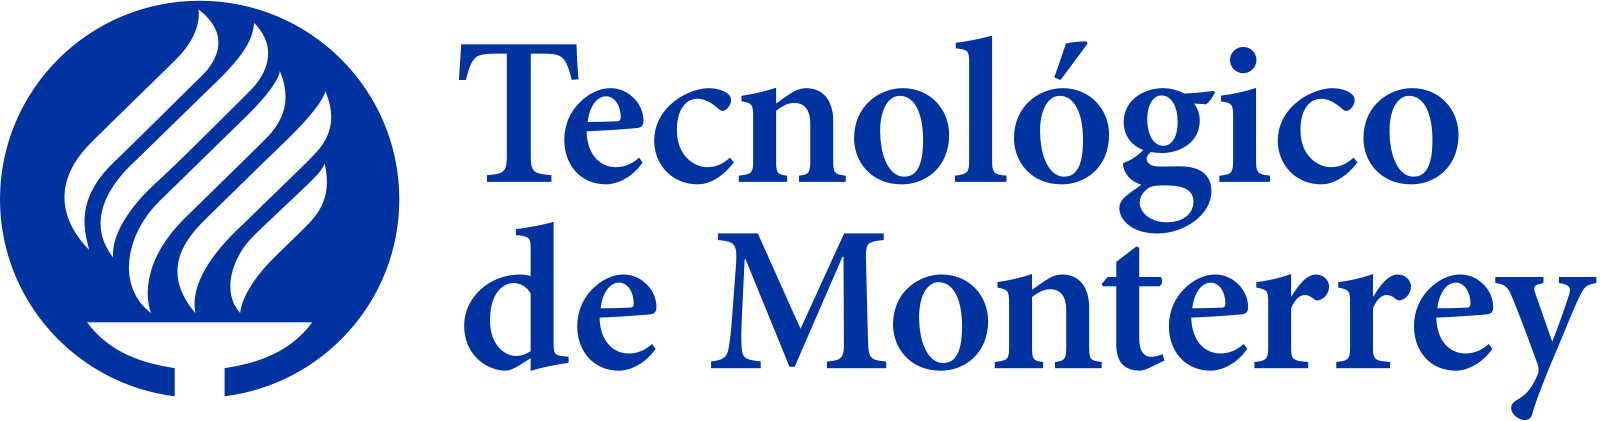

---
# Instituto Tecnológico y de Estudios Superiores de Monterrey


## **Capstone Project (Team #49)**


### **Stage 4.** Alternative models


#### *Author:* Julia Gabriela Pinedo -- A01795315

#### *Professor:* Dr. Grettel Barceló Alonso
#### *Project Advisor:* Dr. Guillermo Mota Medina

---

## Table of Contents
1. [Introduction](#intro)
2. [Algorithms](#algo)
   - [Monte Carlo Policy Gradient](#monte)
   - [Deep Q-Network](#dqn)
   - [Distributional Deep Q-Network](#ddqn)
   - [Soft Actor-Critic](#sac)
   - [Advantage Actor-Critic](#a2c)
   - [Proximal Policy Optimization](#ppo)
3. [Evaluation](#eval)
   - [Final Models](#final)
5. [Adjustments](#ads)
6. [Selected Model](#sel)
7. [References](#references)

---

# Introduction <a class="anchor" id="intro" ></a>

With the infrastructure established in **Stage 1** (Gazebo Harmonic + ROS 2 Jazzy) and the interaction loop running in **Stage 2**, the system is now generating dense and consistent telemetry for the online learning agent (**Figure 1**). Unlike supervised machine learning, there is no fixed dataset here, and the experience is created as the agent acts, through transitions: $(s_{t},a_{t},r_{t},s_{t+1})$. This pattern fits naturally with the formulation of **Markov Decision Processes (MDP)** and a value-based learning framework.

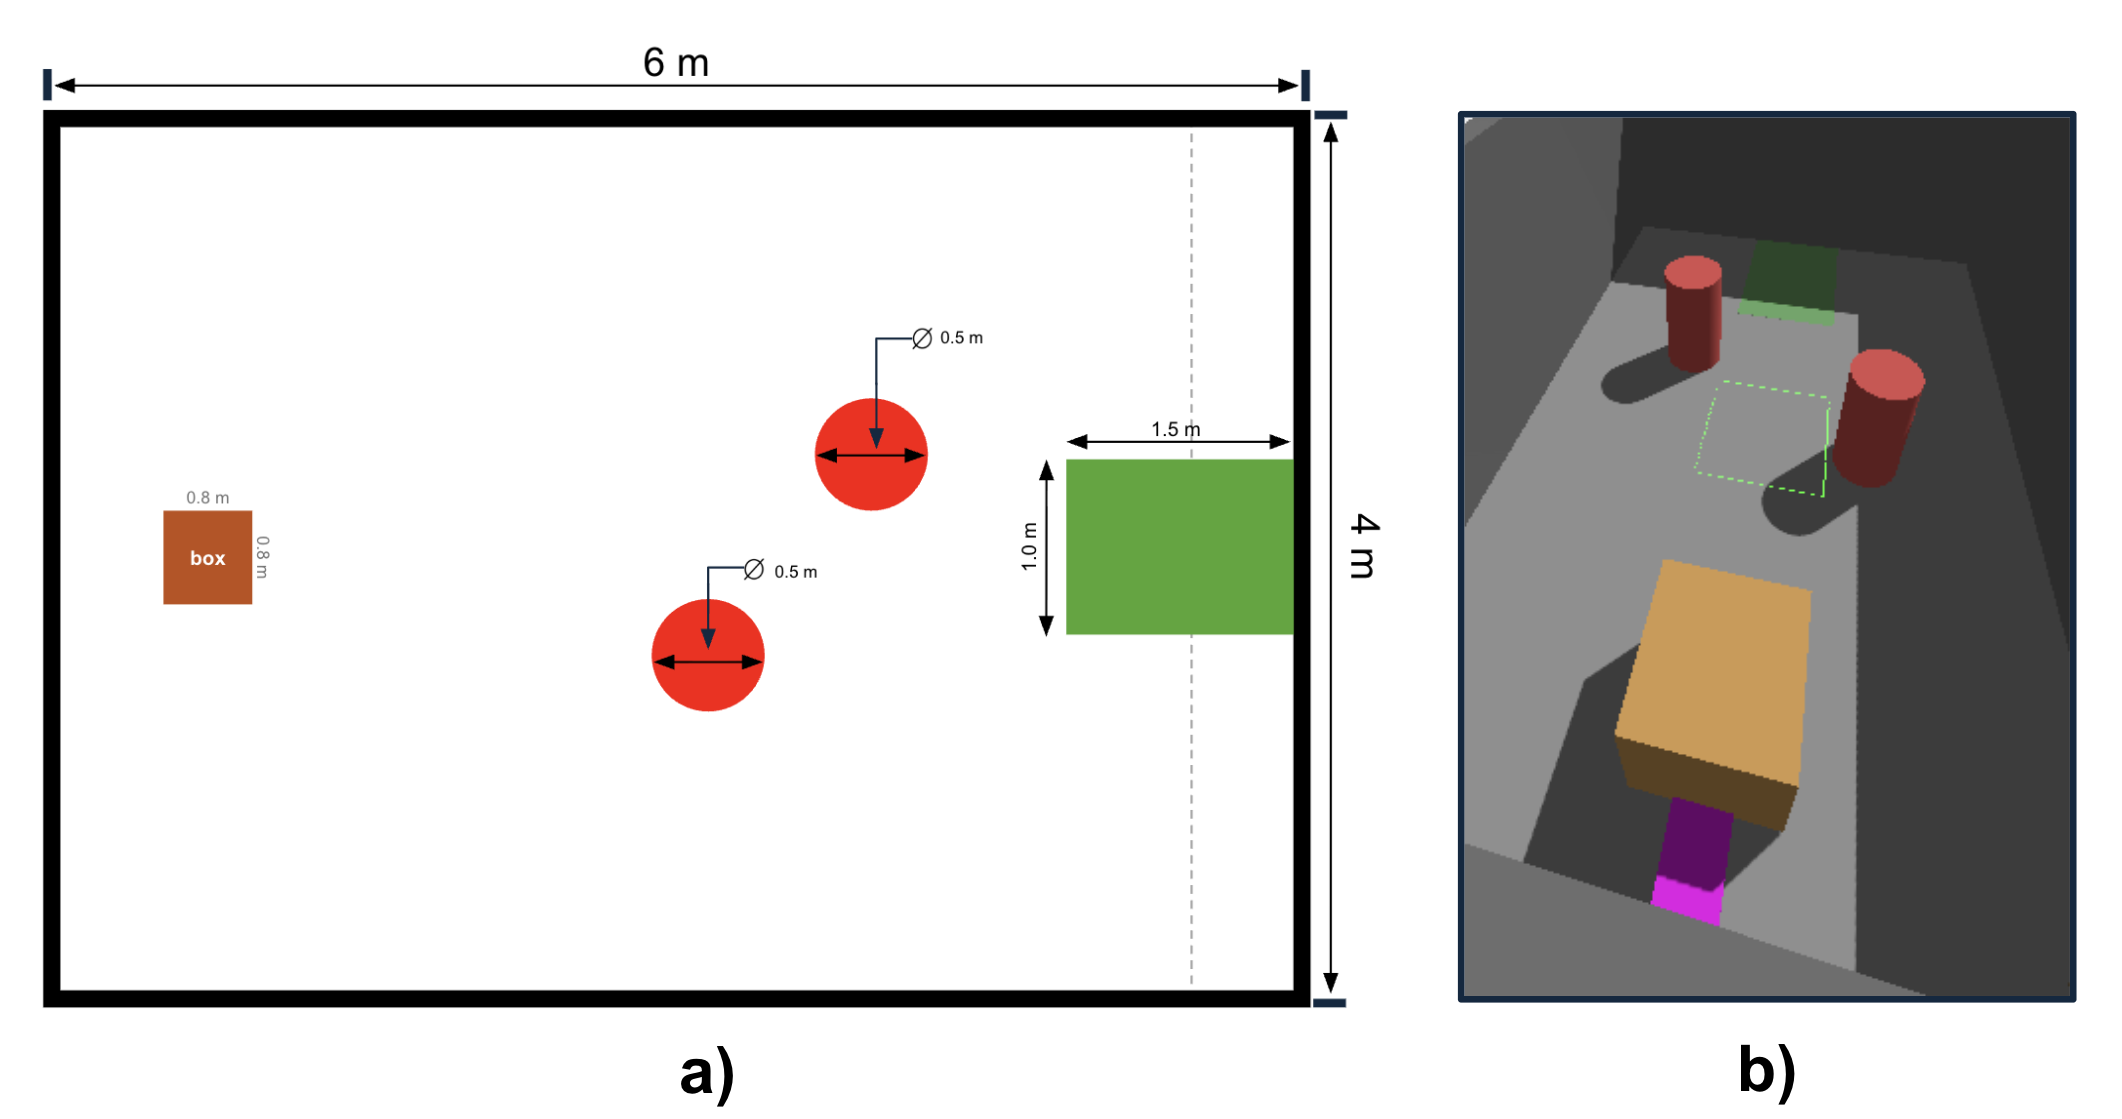
**Figure 1.** Simulation environment. a) Diagram of the arena, b) Arena modeled and simulated in Gazebo.

In **Stage 3**, we chose **Tabular Q-Learning** as the baseline for the following reasons:
- **Problem compatibility:** Observations are structured, numerical, and sequential (poses, velocities, IMU, distances), and control actions are discrete (4 commands). With a coarse discretization (3 bins) of 13 features, we obtain a finite space that preserves the geometry without exploiting complexity.
- **Convergence and traceability:** In finite MDPs, Q-Learning converges under standard assumptions (sufficient exploration, diminishing rates). Furthermore, each $Q(s,a)$ maps to an interpretable physical situation, allowing easy auditing of reward shaping and the effect of exploration.
- **Operational simplicity:** The baseline should be stable, cost-effective, and transparent to establish a performance floor before migrating to function approximation methods.

The agent updates $Q$ using the **Bellman optimality update** [13][14], which iteratively refines expected returns for each state-action pair according to **Equation 1**:

$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + 
\alpha [ r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) ]$ ... **(1)**

This optimizes the expected return per episode. Since the experience is *online* and there is no static train/test, we interleave frozen policy evaluation episodes (without learning, $\varepsilon ≈ \varepsilon_{min}$) to estimate generalization.

---
```python
class QAgent:
    """
    Tabular Q-learning with ε-greedy exploration.
    
    Q-learning update rule:
        Q(s,a) ← Q(s,a) + α[r + γ max_a' Q(s',a') - Q(s,a)]
    """
    def __init__(self, n_actions=4, alpha=0.1, gamma=0.95, eps=1.0, eps_min=0.05, eps_decay=0.99):
        self.nA = n_actions
        self.alpha = alpha          # Learning rate
        self.gamma = gamma          # Discount factor
        self.eps = eps              # Exploration rate
        self.eps_min = eps_min      # Minimum exploration
        self.eps_decay = eps_decay  # Decay rate per episode
        self.Q = {}                 # Q-table: {(state, action): value}

    def _q(self, s, a):
        """Get Q-value with default 0.0 for unseen state-action pairs"""
        return self.Q.get((s, a), 0.0)

    def act(self, s):
        """ε-greedy action selection"""
        if np.random.rand() < self.eps:
            return np.random.randint(self.nA)  # Explore
        else:
            qs = [self._q(s, a) for a in range(self.nA)]
            return int(np.argmax(qs))  # Exploit

    def update(self, s, a, r, s2, done):
        """Q-learning update"""
        if done:
            target = r  # No future reward
        else:
            best_next = max(self._q(s2, a2) for a2 in range(self.nA))
            target = r + self.gamma * best_next
        
        old_q = self._q(s, a)
        self.Q[(s, a)] = old_q + self.alpha * (target - old_q)

    def decay(self):
        """Decay exploration rate"""
        self.eps = max(self.eps_min, self.eps * self.eps_decay)
    
    def save(self, path):
        """Save Q-table and hyperparameters to JSON"""
        os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
        with open(path, 'w') as f:
            # Serialize state tuples as strings
            q_serializable = {f"{s}||{a}": float(v) for (s, a), v in self.Q.items()}
            json.dump({
                'Q': q_serializable,
                'params': {
                    'alpha': float(self.alpha),
                    'gamma': float(self.gamma),
                    'eps': float(self.eps),
                    'nA': int(self.nA)
                }
            }, f, indent=2)
    
    def load(self, path):
        """Load Q-table and hyperparameters from JSON"""
        with open(path, 'r') as f:
            data = json.load(f)
            self.Q = {}
            for key, val in data['Q'].items():
                s_str, a_str = key.rsplit('||', 1)
                s = eval(s_str)  # Convert string back to tuple
                a = int(a_str)
                self.Q[(s, a)] = float(val)
            params = data['params']
            self.alpha = params['alpha']
            self.gamma = params['gamma']
            self.eps = params['eps']
            self.nA = params['nA']
```
---

To evaluate the model, we implemented the following metrics:

1. **Episode return over time (learning curve):** *Are we improving what the agent optimizes?*
2. **Success rate (goal completion):** *Are we completing the task reliably?*
3. **Episode length/steps to success (efficiency):** *Are we completing the task without unnecessary delays?*

This allowed us to establish the following floor criteria:

- **Eval success rate ≥ 0.20:**
A 0.20 floor is a practical threshold that rules out policies that mostly time out or wander, where still being achievable for a simple baseline in a sparse-reward, contact-rich task [9][11].

- **Median steps-to-success ≤ 80 (among successful eval episodes):**
Steps are a proxy for cycle time/energy. Requiring successes to finish well before the 100-step cap ensures we are achieving our goal.


- **Positive learning trend on eval returns in the last ~20 eval points (rolling/local slope > 0):**
This evaluates whether the policy quality is still improving on held-out behavior (not just on noisy training rollouts), indicating the learning is real.


- **No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 return**
Keeping the eval-train gap near zero (or positive) is the RL analog of avoiding overfit.

Obtaining these results for the **Tabular Q-Learning** agent:

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.20 | Yes  |
| Median steps-to-success ≤ 80 | ~50-75 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | Positive learning-curve slope | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | Positive gap  | Yes  |


Meaning that the algorithm meets the **minimum** requirements for reliability, efficiency, and generalization under frozen evaluation. The learning pattern is essentially a “step forward and reduce distance” heuristic, sufficient as a baseline but limited in capturing interactions.

# Algorithms <a class="anchor" id="algo" ></a>

## Monte Carlo Policy Gradient <a class="anchor" id="monte" ></a>

**Monte Carlo Policy Gradient** (also known as *REINFORCE*) is a reinforcement learning approach that optimizes a parameterized policy model for an expected return using gradient ascent. This allows for adjusting a stochastic policy $π_{θ}(a∣s)$, so that actions can become more likely, as it does not learn a value function. It is defined by **Equation 2** [17]:

### Objective and Gradient:

$J(\theta) \;=\; \mathbb{E}_{\tau \sim \pi_\theta}\!\left[\sum_{t=0}^{T-1} G_t \right]$ , 

$\nabla_\theta J(\theta) \;=\; 
\mathbb{E}\!\left[ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\; \big(G_t - b(s_t)\big) \right]$ ... (**2**)

**Where:**

- $π_{θ}(a∣s)$ is the stochastic policy,
- $\tau$ is the trajectory,
- $G_{t}$ is the return from time $t$,
- $γ ∈ [0,1)$ is the discount factor,
- $b(s_{t})$ is the baseline.

### Code Snippet:

---
```python
class REINFORCEAgent:
    """
    Monte Carlo Policy Gradient (REINFORCE) with optional baseline V(s).
    Collect a full episode; call update(traject) once per episode.
    """
    def __init__(self, obs_dim, n_actions, lr=3e-4, gamma=0.99, use_baseline=True):
        self.obs_dim, self.nA = obs_dim, n_actions
        self.gamma = gamma
        self.policy = MLP(obs_dim, n_actions)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.use_baseline = use_baseline
        if use_baseline:
            self.value = MLP(obs_dim, 1)
            self.vopt = optim.Adam(self.value.parameters(), lr=lr)

    def act(self, s):
        with torch.no_grad():
            logits = self.policy(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            a = Categorical(probs).sample().item()
        return a

    def _returns(self, rewards):
        G, out = 0.0, []
        for r in reversed(rewards):
            G = r + self.gamma * G
            out.append(G)
        return list(reversed(out))

    def update(self, traject):
        states = torch.as_tensor(np.array(traject["states"]), dtype=torch.float32)
        actions = torch.as_tensor(traject["actions"], dtype=torch.int64)
        returns = torch.as_tensor(self._returns(traject["rewards"]), dtype=torch.float32)

        logits = self.policy(states)
        logp = torch.log_softmax(logits, dim=-1)
        logp_a = logp[torch.arange(len(actions)), actions]

        if self.use_baseline:
            v = self.value(states).squeeze(-1)
            adv = returns - v.detach()
        else:
            adv = returns

        loss_pi = -(logp_a * adv).mean()
        self.optimizer.zero_grad(); loss_pi.backward(); self.optimizer.step()

        if self.use_baseline:
            loss_v = 0.5 * (returns - v).pow(2).mean()
            self.vopt.zero_grad(); loss_v.backward(); self.vopt.step()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "policy": self.policy.state_dict(),
            "use_baseline": self.use_baseline,
            "gamma": self.gamma,
            "obs_dim": self.obs_dim,
            "nA": self.nA,
            "value": (self.value.state_dict() if self.use_baseline else None),
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.policy.load_state_dict(data["policy"])
        self.gamma = float(data["gamma"])
        self.obs_dim = int(data["obs_dim"]); self.nA = int(data["nA"])
        self.use_baseline = bool(data["use_baseline"])
        if self.use_baseline and data["value"] is not None:
            self.value.load_state_dict(data["value"])
```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| Policy Net | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam  |
| LR Pi | 3e-4  |
| Use Reward to Go | True  |
| Normalize Returns | True  |
| Baseline | value_net  |
| LR V | 3e-4  |
| Entropy Coef | 1e-3  |
| Batch Episodes | 5  |
| Grad Clip | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |


## Deep Q-Network <a class="anchor" id="dqn" ></a>

A **Deep Q-Network** is an RL algorithm that combines Q-Learning with deep neural networks to enable agents to learn optimal actions in complex environments (**Equation 3**). DQN replaces the Q-Learning tabular method by using a neural network that approximates the Q-value function, allowing it to generalize across states and handle high-dimensional inputs. [18]

### TD Target and Loss:

$y \;=\; r \;+\; \gamma \max_{a'} Q_{\mathbf{w}^-}(s', a')$ , 

$L(\mathbf{w}) \;=\; \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} 
\Big( y \;-\; Q_{\mathbf{w}}(s,a) \Big)^2$ ... (**3**)

**Where:**

- $Q_{w}$ is the online network with weights $w$,
- $Q_{w^{-}}$ is the target network,
- $D$ is the replay buffer (randomized transitions),
- $γ$ is the discount factor,
- $r$ is the reward,
- $s'$ is the next state.

These variables are added to reduce moving-target instability and over-estimation.

### Code Snippet:

---
```python
class DQNAgent:
    """
    Double DQN with target network and ε-greedy.
    Call update() every step after filling replay_min.
    """
    def __init__(self, obs_dim, n_actions, lr=1e-3, gamma=0.99,
                 eps=1.0, eps_min=0.05, eps_decay=0.995,
                 replay_size=100_000, replay_min=5_000, batch=256,
                 target_tau=1.0, target_update_every=1000):
        self.obs_dim, self.nA = obs_dim, n_actions
        self.gamma = gamma
        self.eps, self.eps_min, self.eps_decay = eps, eps_min, eps_decay
        self.replay = ReplayBuffer(replay_size)
        self.replay_min, self.batch = replay_min, batch
        self.q = QNet(obs_dim, n_actions)
        self.q_targ = QNet(obs_dim, n_actions)
        self.q_targ.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=lr)
        self.step_count = 0
        self.target_tau = target_tau            # 1.0 = hard copy
        self.target_update_every = target_update_every

    def act(self, s):
        if np.random.rand() < self.eps:
            return np.random.randint(self.nA)
        with torch.no_grad():
            q = self.q(torch.as_tensor(s, dtype=torch.float32))
            return int(torch.argmax(q).item())

    def add(self, s, a, r, s2, done):
        self.replay.add(s, a, r, s2, done)

    def update(self):
        if len(self.replay) < self.replay_min: return
        s,a,r,s2,d = self.replay.sample(self.batch)
        s  = torch.as_tensor(s, dtype=torch.float32)
        a  = torch.as_tensor(a, dtype=torch.int64)
        r  = torch.as_tensor(r, dtype=torch.float32)
        s2 = torch.as_tensor(s2, dtype=torch.float32)
        d  = torch.as_tensor(d, dtype=torch.float32)

        # Double DQN target
        with torch.no_grad():
            q2_online = self.q(s2)                        # for argmax
            a2 = torch.argmax(q2_online, dim=-1)
            q2_targ = self.q_targ(s2)                     # for eval
            y = r + (1.0 - d) * self.gamma * q2_targ.gather(1, a2.unsqueeze(1)).squeeze(1)

        qsa = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = nn.functional.mse_loss(qsa, y)
        self.opt.zero_grad(); loss.backward(); self.opt.step()

        # target net update
        self.step_count += 1
        if self.step_count % self.target_update_every == 0:
            if self.target_tau >= 1.0:
                self.q_targ.load_state_dict(self.q.state_dict())
            else:
                with torch.no_grad():
                    for p, pt in zip(self.q.parameters(), self.q_targ.parameters()):
                        pt.data.mul_(1 - self.target_tau).add_(self.target_tau * p.data)

        # decay epsilon
        self.eps = max(self.eps_min, self.eps * self.eps_decay)

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "q": self.q.state_dict(),
            "q_targ": self.q_targ.state_dict(),
            "eps": self.eps, "gamma": self.gamma,
            "obs_dim": self.obs_dim, "nA": self.nA
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.q.load_state_dict(data["q"])
        self.q_targ.load_state_dict(data["q_targ"])
        self.eps = float(data["eps"]); self.gamma = float(data["gamma"])
        self.obs_dim = int(data["obs_dim"]); self.nA = int(data["nA"])
```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| Q Net | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam  |
| LR Q | 1e-3  |
| Double DQN | True  |
| Replay Buffer | 50000  |
| Batch Size | 64  |
| Target Update | "type": "hard", "every_steps": 1000  |
| Epsilon Schedule | "start": 1.0, "end": 0.05, "decay_steps": 5000  |
| Grad Clip | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |


## Distributional Deep Q-Network <a class="anchor" id="ddqn" ></a>

A **Distributional Deep Q-Network** (also known as *C51*) is a reinforcement learning model that predicts the entire probability distribution of future rewards $Z(s,a)$, rather than just the expected value like a standard DQN (**Equation 4**). This provides a more comprehensive picture of the potential outcomes of an action, as it carries richer learning signals, enhances stability, and enables risk-aware decision-making. [19]

### C51 (categorical) sketch:

$\mathcal{T}Z(s,a) \;\stackrel{D}{=}\; 
r \;+\; \gamma \, Z\!\Big(s', \arg\max_{a'} \mathbb{E}[Z(s',a')]\Big)$ ... (**4**)

This approximates $Z(s,a)$ with quantiles $q_{\tau}$ and minimizes the quantile Huber loss across quantiles, making it more stable and capable of capturing stochasticity.

### Code Snippet:

---
```python
class C51Agent:
    """
    C51 categorical DQN (distributional). Uses projection onto fixed atoms.
    """
    def __init__(self, obs_dim, n_actions, vmin=-10.0, vmax=10.0, n_atoms=51,
                 gamma=0.99, lr=1e-3, eps=1.0, eps_min=0.05, eps_decay=0.995,
                 replay_size=100_000, replay_min=5_000, batch=256, target_update_every=1000):
        self.obs_dim, self.nA = obs_dim, n_actions
        self.gamma, self.vmin, self.vmax, self.n_atoms = gamma, vmin, vmax, n_atoms
        self.agent = C51Head(obs_dim, n_actions, n_atoms, vmin, vmax)
        self.target = C51Head(obs_dim, n_actions, n_atoms, vmin, vmax)
        self.target.load_state_dict(self.agent.state_dict())
        self.opt = optim.Adam(self.agent.parameters(), lr=lr)
        self.replay = ReplayC(replay_size)
        self.replay_min, self.batch = replay_min, batch
        self.eps, self.eps_min, self.eps_decay = eps, eps_min, eps_decay
        self.step_count, self.target_update_every = 0, target_update_every

    def act(self, s):
        if np.random.rand() < self.eps:
            return np.random.randint(self.nA)
        with torch.no_grad():
            q = self.agent.q_values(torch.as_tensor(s, dtype=torch.float32).unsqueeze(0))
            return int(torch.argmax(q, dim=-1).item())

    def add(self, s,a,r,s2,d): self.replay.add(s,a,r,s2,d)

    def _project(self, r, d, next_probs):
        # next_probs: [B, N_atoms] for chosen a*
        B = r.shape[0]
        with torch.no_grad():
            atoms = self.target.atoms  # [N]
            tz = r.unsqueeze(1) + (1.0 - d.unsqueeze(1)) * self.gamma * atoms.view(1, -1)
            tz = tz.clamp(self.vmin, self.vmax)
            b = (tz - self.vmin) / (self.vmax - self.vmin) * (self.n_atoms - 1)
            l = b.floor().to(torch.int64)
            u = b.ceil().to(torch.int64)
            m = torch.zeros(B, self.n_atoms, device=next_probs.device)
            for i in range(self.n_atoms):
                li = l[:, i]; ui = u[:, i]
                w_u = (b[:, i] - li.float()); w_l = (ui.float() - b[:, i])
                m.scatter_add_(1, li.unsqueeze(1), (next_probs[:, i] * w_l).unsqueeze(1))
                m.scatter_add_(1, ui.unsqueeze(1), (next_probs[:, i] * w_u).unsqueeze(1))
        return m

    def update(self):
        if len(self.replay) < self.replay_min: return
        s,a,r,s2,d = self.replay.sample(self.batch)
        s  = torch.as_tensor(s, dtype=torch.float32)
        a  = torch.as_tensor(a, dtype=torch.int64)
        r  = torch.as_tensor(r, dtype=torch.float32)
        s2 = torch.as_tensor(s2, dtype=torch.float32)
        d  = torch.as_tensor(d, dtype=torch.float32)

        with torch.no_grad():
            q_next = self.agent.q_values(s2)                        # online for argmax
            a_star = torch.argmax(q_next, dim=-1)                   # [B]
            p_next_all = self.target(s2)                            # [B, A, N]
            p_next = p_next_all[torch.arange(len(a_star)), a_star]  # [B, N]
            target_dist = self._project(r, d, p_next)               # [B, N_atoms]

        p = self.agent(s)                                           # [B, A, N]
        p_a = p[torch.arange(len(a)), a]                            # [B, N]
        loss = -(target_dist * (p_a.clamp(1e-6,1.0))).log().sum(dim=1).mean()

        self.opt.zero_grad(); loss.backward(); self.opt.step()

        self.step_count += 1
        if self.step_count % self.target_update_every == 0:
            self.target.load_state_dict(self.agent.state_dict())

        self.eps = max(self.eps_min, self.eps * self.eps_decay)

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "agent": self.agent.state_dict(),
            "target": self.target.state_dict(),
            "eps": self.eps,
            "meta": {"obs_dim": self.obs_dim, "nA": self.nA,
                     "vmin": self.vmin, "vmax": self.vmax, "n_atoms": self.n_atoms}
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.agent.load_state_dict(data["agent"])
        self.target.load_state_dict(data["target"])
        self.eps = float(data["eps"])
        self.obs_dim = int(data["meta"]["obs_dim"]); self.nA = int(data["meta"]["nA"])
        self.vmin = float(data["meta"]["vmin"]); self.vmax = float(data["meta"]["vmax"])
        self.n_atoms = int(data["meta"]["n_atoms"])
```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| Q Dist Net | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam  |
| LR Q | 1e-3  |
| Atoms | 51  |
| V Min | -10.0  |
| V Max | 110.0  |
| Replay Buffer | 50000  |
| Batch Size | 64  |
| Target Update | "type": "hard", "every_steps": 1000  |
| Epsilon Schedule | "start": 1.0, "end": 0.05, "decay_steps": 5000  |
| Grad Clip | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |

## Soft Actor-Critic <a class="anchor" id="sac" ></a>

**Soft Actor-Critic** is a state-of-the-art RL algorithm for continuous action spaces. It adopts an off-policy actor-critic approach and uses stochastic policies [13][14]. It uses the maximum entropy formulation to achieve better exploration (**Equations 5-8**).

### Soft RL Objectives:

**Critic (soft Q) target:**

$y \;=\; r \;+\; \gamma \; \mathbb{E}_{a' \sim \pi_\theta(\cdot \mid s')}\!
\big[ Q_{\bar{\psi}}(s',a') - \alpha \log \pi_\theta(a' \mid s') \big]$ ... (**5**)

**Critic loss:**

$L_Q(\psi) \;=\; \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}}
\left[ \big( Q_\psi(s,a) - y \big)^2 \right]$ ... (**6**)

**Actor update:**

$L_{\pi}(\theta) \;=\; 
\mathbb{E}_{s \sim \mathcal{D}}
\!\left[ \mathrm{KL}\!\left(
\pi_\theta(\cdot \mid s) \,\middle\|\, 
\frac{\exp\!\big(\tfrac{1}{\alpha} Q_\psi(s,\cdot)\big)}{Z(s)}
\right) \right]$ ... (**7**)

**Entropy tuning:**

$L(\alpha) \;=\; 
\mathbb{E}_{a \sim \pi_\theta(\cdot \mid s)} 
\!\left[ -\,\alpha \left( \log \pi_\theta(a \mid s) + \mathcal{H}^{\star} \right) \right]$ ... (**8**)

**Where:**

- $Q_{ψ}$ is the soft Q-critic,
- $\bar{\psi}$ is the target critic,
- $α > 0$ is the temperature (higher = more exploration) auto-tuned toward target entropy,
- $Z(s)$ is the normalizer.

### Code Snippet:

---
```python
class SACAgent:
    """
    Discrete-action SAC: twin Q critics, policy over discrete actions, entropy temperature α (fixed).
    """
    def __init__(self, obs_dim, n_actions, lr=3e-4, gamma=0.99, alpha=0.2,
                 replay_size=200_000, replay_min=10_000, batch=256, tau=0.005):
        self.obs_dim, self.nA = obs_dim, n_actions
        self.gamma, self.alpha, self.tau = gamma, alpha, tau
        # Critics (twin)
        self.q1 = QHead(obs_dim, n_actions); self.q2 = QHead(obs_dim, n_actions)
        self.q1_t = QHead(obs_dim, n_actions); self.q2_t = QHead(obs_dim, n_actions)
        self.q1_t.load_state_dict(self.q1.state_dict()); self.q2_t.load_state_dict(self.q2.state_dict())
        self.qopt = optim.Adam(list(self.q1.parameters())+list(self.q2.parameters()), lr=lr)
        # Policy
        self.pi = Policy(obs_dim, n_actions)
        self.piopt = optim.Adam(self.pi.parameters(), lr=lr)
        # Replay
        self.buf = ReplaySAC(replay_size)
        self.replay_min, self.batch = replay_min, batch

    def act(self, s):
        with torch.no_grad():
            probs, _ = self.pi(torch.as_tensor(s, dtype=torch.float32).unsqueeze(0))
            a = Categorical(probs).sample().item()
        return a

    def add(self, s,a,r,s2,d): self.buf.add(s,a,r,s2,d)

    def _soft_update(self, src, tgt):
        with torch.no_grad():
            for p, pt in zip(src.parameters(), tgt.parameters()):
                pt.data.mul_(1 - self.tau).add_(self.tau * p.data)

    def update(self):
        if len(self.buf) < self.replay_min: return
        s,a,r,s2,d = self.buf.sample(self.batch)
        s  = torch.as_tensor(s, dtype=torch.float32)
        a  = torch.as_tensor(a, dtype=torch.int64)
        r  = torch.as_tensor(r, dtype=torch.float32)
        s2 = torch.as_tensor(s2, dtype=torch.float32)
        d  = torch.as_tensor(d, dtype=torch.float32)

        # Critic target
        with torch.no_grad():
            probs2, logp2 = self.pi(s2)
            q1_t = self.q1_t(s2); q2_t = self.q2_t(s2)
            q_min = torch.min(q1_t, q2_t)                            # [B, A]
            v2 = (probs2 * (q_min - self.alpha * logp2)).sum(dim=-1) # soft state value
            y = r + (1.0 - d) * self.gamma * v2

        # Critic loss
        q1 = self.q1(s).gather(1, a.unsqueeze(1)).squeeze(1)
        q2 = self.q2(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss_q = nn.functional.mse_loss(q1, y) + nn.functional.mse_loss(q2, y)
        self.qopt.zero_grad(); loss_q.backward(); self.qopt.step()

        # Policy loss (maximize Q - alpha * logpi)
        probs, logp = self.pi(s)
        with torch.no_grad():
            q1_pi = self.q1(s); q2_pi = self.q2(s)
            q_min_pi = torch.min(q1_pi, q2_pi)
        loss_pi = (probs * (self.alpha * logp - q_min_pi)).sum(dim=-1).mean()
        self.piopt.zero_grad(); loss_pi.backward(); self.piopt.step()

        # Targets
        self._soft_update(self.q1, self.q1_t)
        self._soft_update(self.q2, self.q2_t)

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "q1": self.q1.state_dict(), "q2": self.q2.state_dict(),
            "q1_t": self.q1_t.state_dict(), "q2_t": self.q2_t.state_dict(),
            "pi": self.pi.state_dict(),
            "gamma": self.gamma, "alpha": self.alpha,
            "obs_dim": self.obs_dim, "nA": self.nA
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.q1.load_state_dict(data["q1"]); self.q2.load_state_dict(data["q2"])
        self.q1_t.load_state_dict(data["q1_t"]); self.q2_t.load_state_dict(data["q2_t"])
        self.pi.load_state_dict(data["pi"])
        self.gamma=float(data["gamma"]); self.alpha=float(data["alpha"])
        self.obs_dim=int(data["obs_dim"]); self.nA=int(data["nA"])

```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| Actor | "hidden_sizes": [128, 128], "activation": "relu"  |
| Critic | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam  |
| LR Actor | 3e-4 |
| LR Critic | 3e-4  |
| Target Entropy | -np.log(1.0/4.0)  |
| Alpha | {"auto_tune": True, "lr_alpha": 3e-4}  |
| Tau | 0.005  |
| Replay Buffer | 100000 |
| Batch Size | 128  |
| Grad Clip | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |


## Advantage Actor-Critic <a class="anchor" id="a2c" ></a>

The **Advantage Actor-Critic (A2C)** is an algorithm that combines the strengths of both policy-based and value-based methods in reinforcement learning (**Equation 9**). In this model, a policy (*actor*) is improved using an advantage baseline, while a value function (*critic*) is learned to reduce gradient variance. [13][14]

### Losses (with entropy regularization):

$L_{\pi}(\theta) \;=\; 
-\; \mathbb{E}\!\left[
\log \pi_\theta(a_t \mid s_t)\; \hat{A}_t
\right]
\;-\;
\beta \, \mathbb{E}\!\left[ \mathcal{H}\!\big(\pi_\theta(\cdot \mid s_t)\big) \right]$ ,

$L_{V}(\phi) \;=\; 
\mathbb{E}\!\left[ \big( V_\phi(s_t) - \hat{V}_t \big)^2 \right]$ ... (**9**)

**Where:**

- $π_{θ}$ is the policy,
- $V_{ϕ}$ is the value network,
- $\hat{A}_t$ is the advantage estimate,
- $𝛽$ is the entropy weight to encourage exploration.

### Code Snippet:

---
```python
class A2CAgent:
    """
    On-policy Advantage Actor-Critic.
    Collect rollout of T steps; then call update(rollout_dict).
    """
    def __init__(self, obs_dim, n_actions, lr=3e-4, gamma=0.99, lam=0.95, ent_coef=0.01, vf_coef=0.5):
        self.gamma, self.lam = gamma, lam
        self.ent_coef, self.vf_coef = ent_coef, vf_coef
        self.net = PiV(obs_dim, n_actions)
        self.opt = optim.Adam(self.net.parameters(), lr=lr)
        self.nA = n_actions

    def act(self, s):
        with torch.no_grad():
            logits, _ = self.net(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            a = Categorical(probs).sample().item()
        return a

    def _gae(self, rewards, values, dones, last_value):
        T = len(rewards)
        adv = torch.zeros(T, dtype=torch.float32)
        gae = 0.0
        for t in reversed(range(T)):
            delta = rewards[t] + self.gamma * (1.0 - dones[t]) * (last_value if t==T-1 else values[t+1]) - values[t]
            gae = delta + self.gamma * self.lam * (1.0 - dones[t]) * gae
            adv[t] = gae
        returns = adv + values
        return adv, returns

    def update(self, rollout):
        states = torch.as_tensor(np.array(rollout["states"]), dtype=torch.float32)
        actions = torch.as_tensor(rollout["actions"], dtype=torch.int64)
        rewards = torch.as_tensor(rollout["rewards"], dtype=torch.float32)
        dones = torch.as_tensor(rollout["dones"], dtype=torch.float32)
        next_state = torch.as_tensor(rollout["next_state"], dtype=torch.float32)

        logits, values = self.net(states)
        with torch.no_grad():
            _, last_v = self.net(next_state.unsqueeze(0))
            last_v = last_v.squeeze(0)
        adv, ret = self._gae(rewards, values.detach(), dones, last_v)

        logp = torch.log_softmax(logits, dim=-1)
        logp_a = logp[torch.arange(len(actions)), actions]
        ent = -(torch.softmax(logits, -1) * logp).sum(-1).mean()

        loss_pi = -(logp_a * adv).mean()
        loss_v  = 0.5 * (ret - values).pow(2).mean()
        loss = loss_pi + self.vf_coef * loss_v - self.ent_coef * ent

        self.opt.zero_grad(); loss.backward(); self.opt.step()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({"net": self.net.state_dict()}, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.net.load_state_dict(data["net"])
```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| GAE Lambda | 0.95  |
| Actor | "hidden_sizes": [128, 128], "activation": "relu"  |
| Critic | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam |
| LR Actor | 3e-4  |
| LR Critic | 3e-4  |
| Entropy Coef | 0.01  |
| Value Coef | 0.5  |
| Rollout Len | 20 |
| Num Workers | 1  |
| Grad Clip | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |

## Proximal Policy Optimization <a class="anchor" id="ppo" ></a>

**Proximal Policy Optimization (PPO)** is an RL algorithm that focuses on simplicity, stability, and sample efficiency. [13][14] PPO is a policy gradient method for training an agent’s policy network. This policy-gradient method constraints updates using a clipped surrogate objective (**Equations 10-11**).

### Clipped surrogate + value + entropy:

$r_t(\theta) \;=\; \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}$ ,

$L^{\text{CLIP}}(\theta) \;=\; 
\mathbb{E}\!\left[
\min\!\Big( r_t(\theta)\, \hat{A}_t,\;
\text{clip}\!\big( r_t(\theta),\, 1-\varepsilon,\, 1+\varepsilon \big)\, \hat{A}_t
\Big)
\right]$ ... (**10**)

$L(\theta,\phi) \;=\;
\mathbb{E}\!\big[ L^{\text{CLIP}}(\theta) \big]
\;-\;
c_V \, \mathbb{E}\!\big[(V_\phi(s_t) - \hat{V}_t)^2\big]
\;+\;
c_H \, \mathbb{E}\!\big[\mathcal{H}(\pi_\theta(\cdot \mid s_t))\big]$ ... (**11**)

**Where:**

- $r_{t}(θ)$ is the probability ratio (new/old policy),
- $\epsilon$ is the clip range,
- $c_{V}, c_{H}$ is the value and entropy loss weights,
- $\hat{A}_t$ is the advantage (often GAE).

### Code Snippet:

---
```python
class PPOAgent:
    """
    PPO-Clip (discrete). Use rollout storage with old log-probs.
    """
    def __init__(self, obs_dim, n_actions, lr=3e-4, gamma=0.99, lam=0.95,
                 clip_eps=0.2, ent_coef=0.01, vf_coef=0.5, epochs=4, batch_size=2048, minibatch=256):
        self.gamma, self.lam = gamma, lam
        self.clip_eps, self.ent_coef, self.vf_coef = clip_eps, ent_coef, vf_coef
        self.epochs, self.minibatch = epochs, minibatch
        self.net = ActorCritic(obs_dim, n_actions)
        self.opt = optim.Adam(self.net.parameters(), lr=lr)
        self.batch_size = batch_size
        self.nA = n_actions

    def act(self, s):
        with torch.no_grad():
            logits, v = self.net(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            dist = Categorical(probs)
            a = dist.sample()
            logp = dist.log_prob(a)
        return int(a.item()), float(logp.item()), float(v.item())

    def _gae(self, rewards, values, dones, last_value):
        T = len(rewards)
        adv = torch.zeros(T, dtype=torch.float32)
        gae = 0.0
        for t in reversed(range(T)):
            delta = rewards[t] + self.gamma * (1.0 - dones[t]) * (last_value if t==T-1 else values[t+1]) - values[t]
            gae = delta + self.gamma * self.lam * (1.0 - dones[t]) * gae
            adv[t] = gae
        ret = adv + values
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        return adv, ret

    def update(self, rollout):
        # flatten rollout
        states = torch.as_tensor(np.array(rollout["states"]), dtype=torch.float32)
        actions = torch.as_tensor(rollout["actions"], dtype=torch.int64)
        rewards = torch.as_tensor(rollout["rewards"], dtype=torch.float32)
        dones = torch.as_tensor(rollout["dones"], dtype=torch.float32)
        old_logp = torch.as_tensor(rollout["old_logp"], dtype=torch.float32)
        next_state = torch.as_tensor(rollout["next_state"], dtype=torch.float32)

        logits, values = self.net(states)
        with torch.no_grad():
            _, last_v = self.net(next_state.unsqueeze(0))
            last_v = last_v.squeeze(0)
        adv, ret = self._gae(rewards, values.detach(), dones, last_v)

        N = states.size(0)
        idx = np.arange(N)
        for _ in range(self.epochs):
            np.random.shuffle(idx)
            for start in range(0, N, self.minibatch):
                j = idx[start:start+self.minibatch]
                sB, aB, oldB, advB, retB = states[j], actions[j], old_logp[j], adv[j], ret[j]

                logitsB, vB = self.net(sB)
                probsB = torch.softmax(logitsB, dim=-1)
                distB = Categorical(probsB)
                logpB = distB.log_prob(aB)
                ratio = torch.exp(logpB - oldB)

                clip_adv = torch.clamp(ratio, 1.0 - self.clip_eps, 1.0 + self.clip_eps) * advB
                loss_pi = -(torch.min(ratio * advB, clip_adv)).mean()
                ent = distB.entropy().mean()
                loss_v = 0.5 * (retB - vB).pow(2).mean()

                loss = loss_pi + self.vf_coef * loss_v - self.ent_coef * ent
                self.opt.zero_grad(); loss.backward(); self.opt.step()

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({"net": self.net.state_dict()}, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.net.load_state_dict(data["net"])
```
---

### List of Parameters:

| Param | Content |
|:-------------|:-----------|
| Gamma | 0.99 |
| GAE Lambda | 0.95  |
| Policy | "hidden_sizes": [128, 128], "activation": "relu"  |
| Optimizer | adam |
| LR Policy | 3e-4  |
| Clip Ratio | 0.2  |
| Entropy Coef | 0.01  |
| Value Coef | 0.5  |
| Rollout Len | 512 |
| Epochs per Rollout | 10  |
| Minibatch Size | 128  |
| Max Grad Norm | 0.5  |
| Episodes | 100  |
| Max Steps | 100  |


# Evaluation <a class="anchor" id="eval" ></a>

## Global Libraries

Since ROS2 and Gazebo are not designed to run natively in Jupyter (*the jupyter-ros2 library is not compatible with our current computational setup*), the RL agent logs all training artifacts online to files:

- episode metrics (`{model_name}_metrics.jsonl`),
- step rollouts (`{model_name}_rollouts.csv`).

The notebook will ingest these artifacts for evaluation and visualization without requiring the simulator to run inside Jupyter.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Paths for each model

# Monte Carlo Policy Gradient
MCPG_METRICS = Path("/Users/juliapinedo/Desktop/data/mcpg_metrics.jsonl")

# Deep Q-Network
DQN_METRICS = Path("/Users/juliapinedo/Desktop/data/dqn_metrics.jsonl")

# Distributional Deep Q-Network
DDQN_METRICS = Path("/Users/juliapinedo/Desktop/data/c51_metrics.jsonl")

# Soft Actor-Critic
SAC_METRICS = Path("/Users/juliapinedo/Desktop/data/sac_metrics.jsonl")

# Advantage Actor-Critic
A2C_METRICS = Path("/Users/juliapinedo/Desktop/data/a2c_metrics.jsonl")

# Proximal Policy Optimization
PPO_METRICS = Path("/Users/juliapinedo/Desktop/data/ppo_metrics.jsonl")

In [3]:
# Custom function to retrieve the jsonl
def load_metrics_json_any(p: Path) -> pd.DataFrame:
    if not p.exists():
        raise FileNotFoundError(f"No existe: {p}")
    if p.stat().st_size == 0:
        return pd.DataFrame()
    try:
        with p.open("r", encoding="utf-8") as fh:
            return pd.read_json(fh, lines=True)
    except ValueError:
        pass
    try:
        with p.open("r", encoding="utf-8") as fh:
            first = fh.read(1)
            fh.seek(0)
            if first in "[{":
                return pd.read_json(fh)
    except ValueError:
        pass
    rows = []
    with p.open("r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

In [4]:
# Retrieve the jsonl and csv per model

# Monte Carlo Policy Gradient

mcpg_metrics = load_metrics_json_any(MCPG_METRICS)
mcpg_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.440251,90,0,0.800000,0,4.592765,Monte Carlo Policy Gradient,100,5
1,2,7.576430,52,1,0.792929,0,2.692404,Monte Carlo Policy Gradient,100,5
2,3,0.511687,98,0,0.785859,0,5.000560,Monte Carlo Policy Gradient,100,5
3,4,0.269948,73,0,0.778788,0,3.759503,Monte Carlo Policy Gradient,100,5
4,5,0.284479,94,0,0.771717,1,4.794385,Monte Carlo Policy Gradient,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,9.881198,65,1,0.128283,0,3.315426,Monte Carlo Policy Gradient,100,5
96,97,9.655858,46,1,0.121212,0,2.426368,Monte Carlo Policy Gradient,100,5
97,98,9.954634,74,1,0.114141,0,3.789650,Monte Carlo Policy Gradient,100,5
98,99,0.681876,87,0,0.107071,0,4.475497,Monte Carlo Policy Gradient,100,5


In [5]:
# Deep Q-Network

dqn_metrics = load_metrics_json_any(DQN_METRICS)
dqn_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.578680,99,0,0.800000,0,5.066314,Deep Q-Network,100,5
1,2,0.159755,73,0,0.792929,0,3.776284,Deep Q-Network,100,5
2,3,0.233888,86,0,0.785859,0,4.412647,Deep Q-Network,100,5
3,4,0.309784,98,0,0.778788,0,4.999927,Deep Q-Network,100,5
4,5,7.601648,60,1,0.771717,1,3.107933,Deep Q-Network,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,0.472026,90,0,0.128283,0,4.606714,Deep Q-Network,100,5
96,97,0.576552,86,0,0.121212,0,4.412538,Deep Q-Network,100,5
97,98,0.565968,70,0,0.114141,0,3.591343,Deep Q-Network,100,5
98,99,9.651953,47,1,0.107071,0,2.462949,Deep Q-Network,100,5


In [6]:
# Distributional Deep Q-Network

ddqn_metrics = load_metrics_json_any(DDQN_METRICS)
ddqn_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.182177,74,0,0.800000,0,3.822241,Distributional Deep Q-Network,100,5
1,2,5.808420,45,1,0.792929,0,2.346491,Distributional Deep Q-Network,100,5
2,3,0.171949,76,0,0.785859,0,3.881940,Distributional Deep Q-Network,100,5
3,4,5.921603,49,1,0.778788,0,2.541841,Distributional Deep Q-Network,100,5
4,5,0.424790,79,0,0.771717,1,4.049277,Distributional Deep Q-Network,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,7.419734,74,1,0.128283,0,3.822031,Distributional Deep Q-Network,100,5
96,97,0.393287,92,0,0.121212,0,4.701018,Distributional Deep Q-Network,100,5
97,98,0.440598,79,0,0.114141,0,4.071222,Distributional Deep Q-Network,100,5
98,99,7.613728,73,1,0.107071,0,3.779847,Distributional Deep Q-Network,100,5


In [7]:
# Soft Actor-Critic

sac_metrics = load_metrics_json_any(SAC_METRICS)
sac_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.720917,97,0,0.800000,0,4.974312,Soft Actor-Critic,100,5
1,2,7.033660,75,1,0.792929,0,3.842859,Soft Actor-Critic,100,5
2,3,0.343252,94,0,0.785859,0,4.794934,Soft Actor-Critic,100,5
3,4,0.228473,80,0,0.778788,0,4.096114,Soft Actor-Critic,100,5
4,5,7.304846,74,1,0.771717,1,3.818554,Soft Actor-Critic,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,0.350159,90,0,0.128283,0,4.578642,Soft Actor-Critic,100,5
96,97,0.398157,76,0,0.121212,0,3.896410,Soft Actor-Critic,100,5
97,98,0.415648,90,0,0.114141,0,4.619336,Soft Actor-Critic,100,5
98,99,0.565885,73,0,0.107071,0,3.769446,Soft Actor-Critic,100,5


In [8]:
# Advantage Actor-Critic

a2c_metrics = load_metrics_json_any(A2C_METRICS)
a2c_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.236030,70,0,0.800000,0,3.583558,Advantage Actor-Critic,100,5
1,2,4.899050,74,1,0.792929,0,3.788180,Advantage Actor-Critic,100,5
2,3,4.900434,74,1,0.785859,0,3.818872,Advantage Actor-Critic,100,5
3,4,4.888697,63,1,0.778788,0,3.258959,Advantage Actor-Critic,100,5
4,5,5.032810,73,1,0.771717,1,3.769958,Advantage Actor-Critic,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,6.138279,58,1,0.128283,0,3.035485,Advantage Actor-Critic,100,5
96,97,0.597766,99,0,0.121212,0,5.087949,Advantage Actor-Critic,100,5
97,98,0.413049,71,0,0.114141,0,3.669299,Advantage Actor-Critic,100,5
98,99,0.394570,89,0,0.107071,0,4.527915,Advantage Actor-Critic,100,5


In [9]:
# Proximal Policy Optimization

ppo_metrics = load_metrics_json_any(PPO_METRICS)
ppo_metrics

,episode,return,steps,success,epsilon,eval_mode,episode_duration_sec,algo,max_steps,eval_every
0,1,0.197268,87,0,0.800000,0,4.445335,Proximal Policy Optimization,100,5
1,2,0.253193,83,0,0.792929,0,4.282002,Proximal Policy Optimization,100,5
2,3,4.941662,49,1,0.785859,0,2.543321,Proximal Policy Optimization,100,5
3,4,4.865986,57,1,0.778788,0,2.969650,Proximal Policy Optimization,100,5
4,5,5.131220,75,1,0.771717,1,3.829055,Proximal Policy Optimization,100,5
...,...,...,...,...,...,...,...,...,...,...
95,96,6.116317,62,1,0.128283,0,3.236754,Proximal Policy Optimization,100,5
96,97,6.030348,52,1,0.121212,0,2.678259,Proximal Policy Optimization,100,5
97,98,6.160516,72,1,0.114141,0,3.698325,Proximal Policy Optimization,100,5
98,99,6.218955,53,1,0.107071,0,2.723815,Proximal Policy Optimization,100,5


In Reinforcement Learning, the canonical objective is the **expected return**: the sum of rewards within an episode [14]. For this task, the reward is dominated by forward progress (plus small step/rotation penalties and a terminal goal bonus), so a higher return can be close to more progress, fewer wasted steps, and reaching the goal more often. Because experience is generated online and the state distribution shifts as the policy improves, we evaluate on interleaved, frozen-policy evaluation episodes and compare them to training episodes. This is the RL analog of train/test.

## Core evaluation metrics

1. **Episode return over time (learning curve):**

In RL, the objective is to maximize the discounted sum of rewards over an episode **(Equation 12)**:


$G_t=\sum_{k=0}^{T-t-1}\gamma^k R_{t+k+1}$ … **(12)**

Plotting episode return across training/evaluation episodes is the canonical way to see whether the policy is improving the very quantity it optimizes. For this task, the reward is explicitly shaped around forward progress (and a terminal bonus on goal), so rising evaluation returns indicate the robot is more reliably pushing the box into the goal under a frozen policy. This is important on standard RL foundations, where return is the optimization target and learning curves are the primary diagnostic for policy improvement.

2. **Success rate (goal completion):**

Return depends on reward shaping, but success does not. Tracking the fraction of episodes that end with the box fully inside the goal region gives a task completion metric that maps directly to operational success. In the multi-robot literature [6][8][9], completion rate is a staple outcome metric because it is easy to interpret for stakeholders and robust to details of the stepwise reward.


3. **Episode length/steps to success (efficiency):**

Among successful episodes, fewer steps mean higher throughput and lower energy/time cost. Tracking the distribution of steps to success complements the success rate. A policy that finishes more often and faster is preferable to one that finishes only by taking excessively long detours.

In [10]:
# ***************************** HELPER METHODS ******************************
def rolling_mean(series, w=7):
    return series.rolling(w, min_periods=1).mean()

def align_train_on_eval(train_eps, train_vals, eval_eps):
    if len(train_eps) == 0 or len(eval_eps) == 0:
        return np.full(len(eval_eps), np.nan, dtype=float)
    order = np.argsort(train_eps)
    te = np.asarray(train_eps, dtype=float)[order]
    tv = np.asarray(train_vals, dtype=float)[order]
    ee = np.asarray(eval_eps, dtype=float)
    ee_clip = np.clip(ee, te.min(), te.max())
    return np.interp(ee_clip, te, tv)

def moving_slope(y, w=9):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    s = np.full(len(y), np.nan)
    for i in range(len(y)):
        j0 = max(0, i - w + 1)
        xi, yi = x[j0:i+1], y[j0:i+1]
        mask = np.isfinite(yi)
        if mask.sum() >= 3:
            s[i] = np.polyfit(xi[mask], yi[mask], 1)[0]
    return s

# *************************** MINIMUM THRESHOLDS ****************************
MIN_SUCCESS = 0.20
MAX_MEDIAN_STEPS = 80
MIN_SLOPE_LAST = 0.0
MIN_GAP = -1.0  # eval − train

# ***************************** METRIC ANALYZER *****************************
def analyze_model(metrics_df, model_name="MODEL", w=7, slope_tail_eval_points=20):
    req = ["episode","return","steps","success","eval_mode"]
    for c in req:
        if c not in metrics_df.columns:
            raise ValueError(f"[{model_name}] missing required column: {c}")

    # 1) Prep & rolling
    M = metrics_df.sort_values("episode").reset_index(drop=True).copy()
    M["success"] = M["success"].astype(float)
    M["return_smooth"]  = rolling_mean(M["return"].astype(float),  w=w)
    M["success_smooth"] = rolling_mean(M["success"].astype(float), w=w)

    is_eval  = (M["eval_mode"] == 1)
    is_train = ~is_eval

    # 2) Streams for gap/slope (returns)
    train_returns = M.loc[is_train, "return"].reset_index(drop=True)
    eval_returns  = M.loc[is_eval,  "return"].reset_index(drop=True)
    train_smooth  = rolling_mean(train_returns, w=w).values
    eval_smooth   = rolling_mean(eval_returns,  w=w).values
    train_eps = M.loc[is_train, "episode"].values
    eval_eps  = M.loc[is_eval,  "episode"].values
    train_on_eval = align_train_on_eval(train_eps, train_smooth, eval_eps)
    gap = eval_smooth - train_on_eval
    mean_gap = float(np.nanmean(gap)) if len(gap) else np.nan

    # Tail slope on eval returns
    if len(eval_smooth) >= 3:
        tlen  = min(slope_tail_eval_points, len(eval_smooth))
        tail  = eval_smooth[-tlen:]
        x_tail = np.arange(len(tail), dtype=float)
        eval_tail_slope = float(np.polyfit(x_tail, tail, 1)[0])
    else:
        eval_tail_slope = np.nan

    # Success curves per stream
    succ_train = rolling_mean(M.loc[is_train, "success"].reset_index(drop=True), w=w).values
    succ_eval  = rolling_mean(M.loc[is_eval,  "success"].reset_index(drop=True), w=w).values
    succ_train_eps = M.loc[is_train, "episode"].values
    succ_eval_eps  = M.loc[is_eval,  "episode"].values

    # Success stats
    eval_success_rate  = float(M.loc[is_eval, "success"].mean()) if is_eval.any() else np.nan
    eval_success_steps = M.loc[is_eval & (M["success"]==1), "steps"].values
    eval_median_steps  = float(np.median(eval_success_steps)) if len(eval_success_steps) else np.nan

    mean_return_train = float(M.loc[is_train, "return"].mean()) if is_train.any() else np.nan
    mean_return_eval  = float(M.loc[is_eval,  "return"].mean())  if is_eval.any()  else np.nan

    # 3) One-row figure
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

    # (A) Episode return over time
    ax = axes[0]
    ax.plot(M.loc[is_train, "episode"], M.loc[is_train, "return"], ".", alpha=0.30, label="train (raw)")
    ax.plot(M.loc[is_eval,  "episode"], M.loc[is_eval,  "return"],  "x", alpha=0.60, label="eval (raw)")
    ax.plot(M["episode"], M["return_smooth"], "-", label=f"all (rolling {w})")
    ax.set_title(f"[{model_name}] Return over time"); ax.set_xlabel("Episode"); ax.set_ylabel("Return")
    ax.legend(loc="best", fontsize=8)

    # (B) Success rate over time
    ax = axes[1]
    ax.scatter(M.loc[is_train, "episode"], M.loc[is_train, "success"],
               s=10, alpha=0.25, label="train success (raw)")
    ax.scatter(M.loc[is_eval,  "episode"], M.loc[is_eval,  "success"],
               s=16, alpha=0.40, marker="x", label="eval success (raw)")
    ax.plot(succ_train_eps, succ_train, "-", label=f"train success (rolling {w})")
    ax.plot(succ_eval_eps,  succ_eval,  "-", label=f"eval success (rolling {w})")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"[{model_name}] Success rate (train vs eval)")
    ax.set_xlabel("Episode"); ax.set_ylabel("Success (0/1)")
    ax.legend(loc="best", fontsize=8)

    # (C) Episode steps
    ax = axes[2]
    ax.plot(M["episode"], M["steps"], ".", alpha=0.5)
    ax.set_title(f"[{model_name}] Episode steps"); ax.set_xlabel("Episode"); ax.set_ylabel("Steps")

    # (D) Generalization gap at eval points
    ax = axes[3]
    if len(eval_eps) == len(gap) and len(gap) > 0:
        ax.plot(eval_eps, gap, "-o", label="Eval − Train")
        ax.axhline(0, ls="--", color="gray")
        ax.legend(loc="best", fontsize=8)
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"[{model_name}] Gap (eval points)"); ax.set_xlabel("Episode"); ax.set_ylabel("Return gap")

    plt.show()

    # 4) Summary DataFrame
    summary = pd.DataFrame([{
        "model": model_name,
        "eval_success_rate": eval_success_rate,
        "eval_median_steps_success": eval_median_steps,
        "eval_tail_return_slope": eval_tail_slope,
        "mean_eval_minus_train_gap": mean_gap,
        "mean_return_train": mean_return_train,
        "mean_return_eval": mean_return_eval,
    }])
    return summary

In [11]:
# ****************** LOOP TO ANALYZE ALL MODELS AT ONCE *********************

def analyze_all_models_from_dfs(dfs: dict, w=7, slope_tail_eval_points=20):
    all_rows = []
    for name, df in dfs.items():
        try:
            print(f"{name.upper()}")
            summary = analyze_model(
                metrics_df=df,
                model_name=name.upper(),
                w=w,
                slope_tail_eval_points=slope_tail_eval_points
            )
            display(summary)  # Per-model numeric table
            all_rows.append(summary)
            print("\n")
        except Exception as e:
            print(f"[{name}] error: {e}")

    if not all_rows:
        return pd.DataFrame()

    out = pd.concat(all_rows, ignore_index=True)

    # Order by eval_success_rate (desc), keep others stable as tiebreakers if present
    order_cols = [c for c in ["eval_success_rate",
                              "PASS_success_rate",
                              "eval_median_steps_success"] if c in out.columns]
    if "eval_success_rate" in out.columns:
        out = out.sort_values(by="eval_success_rate", ascending=False, kind="mergesort").reset_index(drop=True)

    return out

MCPG


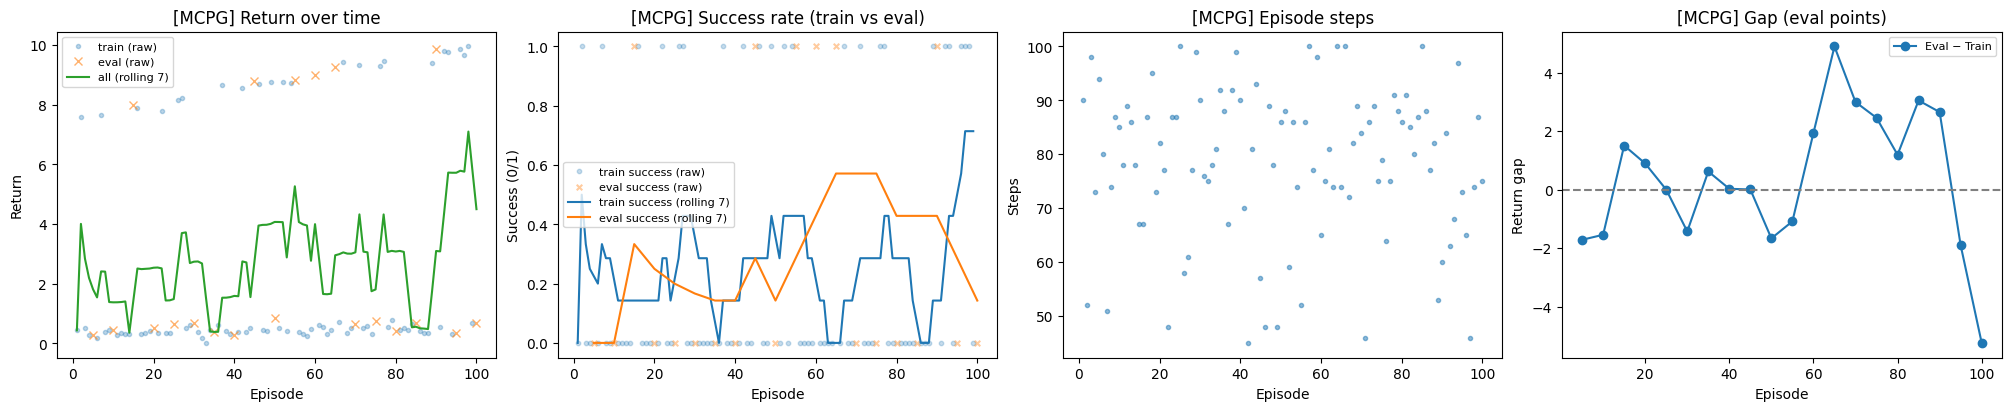

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,MCPG,0.3,62.5,0.176202,0.382807,2.751255,3.070186




DQN


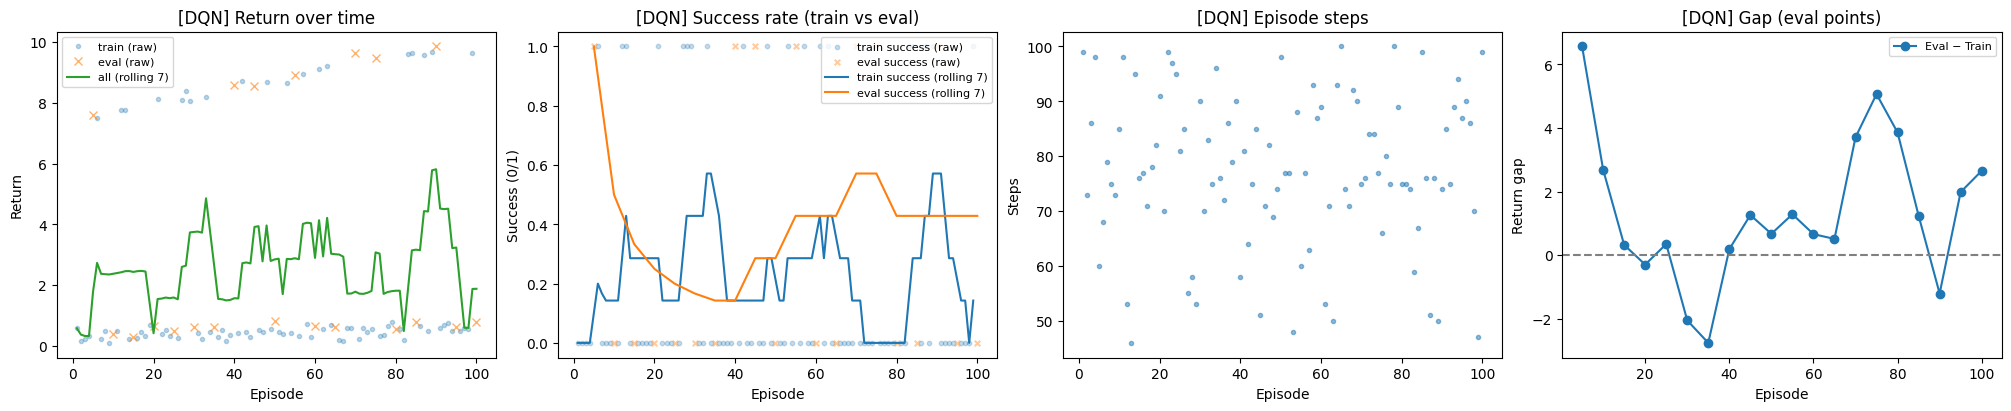

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,DQN,0.35,60.0,0.083728,1.33555,2.399842,3.526415




DDQN


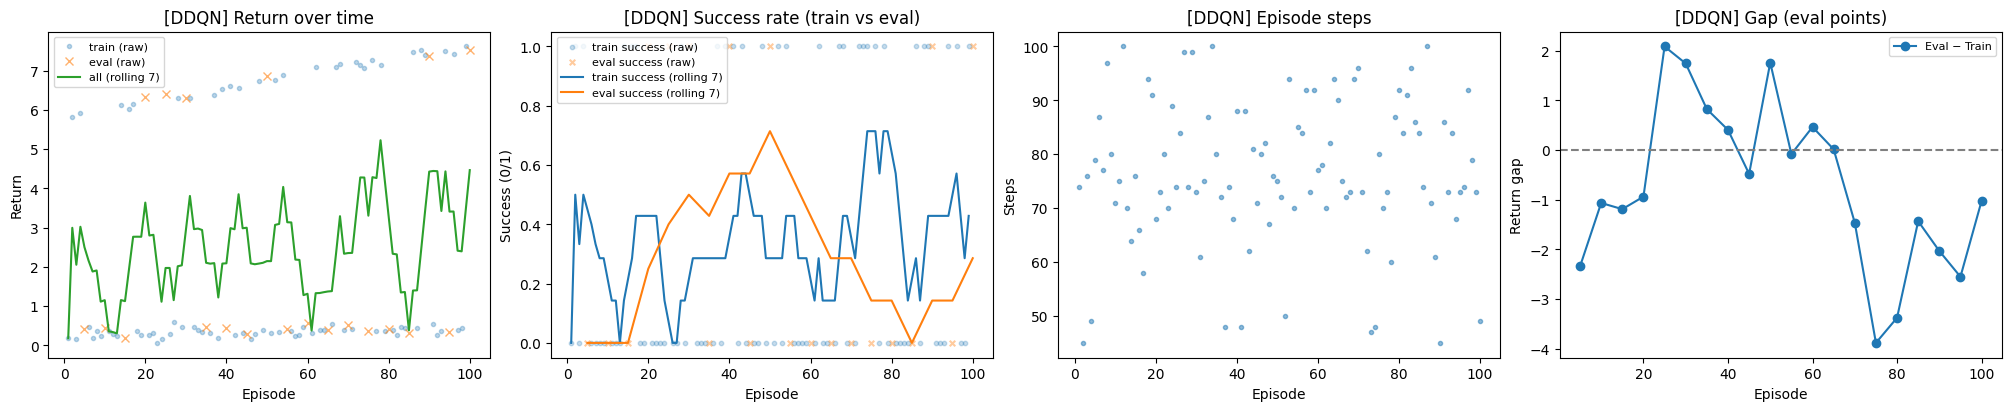

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,DDQN,0.35,73.0,-0.002641,-0.726385,2.610442,2.317742




SAC


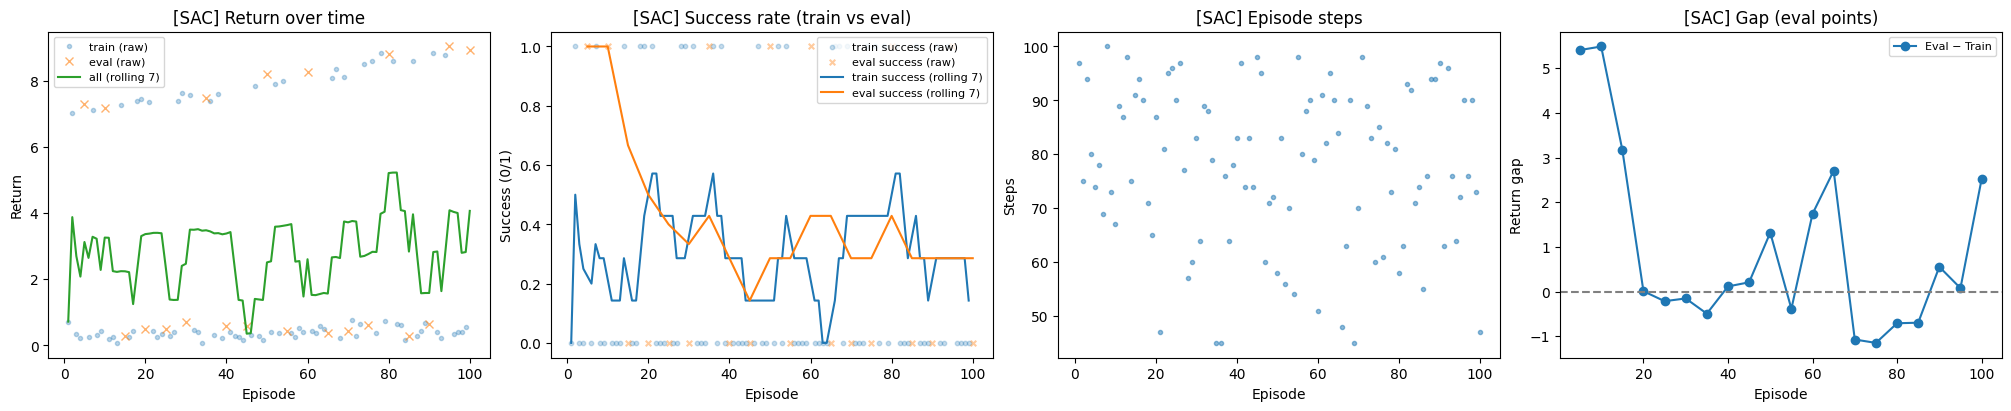

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,SAC,0.35,58.0,-0.124585,0.921011,2.639946,3.558082




A2C


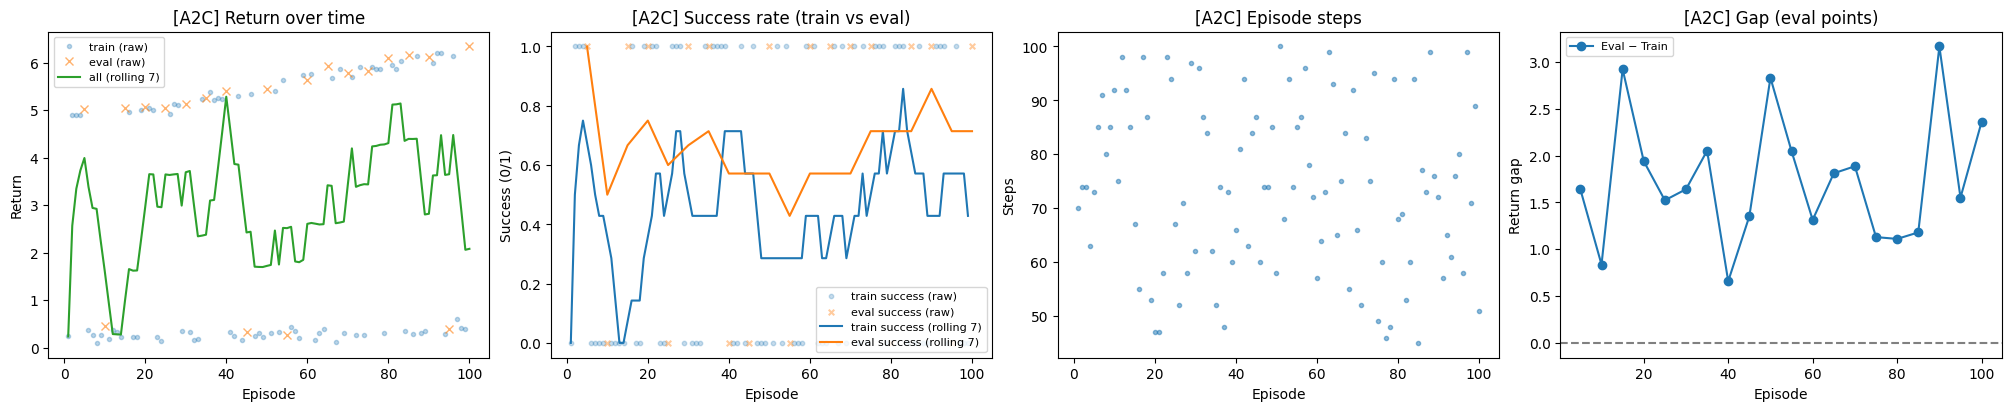

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.65,58.0,0.074905,1.747696,2.637673,4.536619




PPO


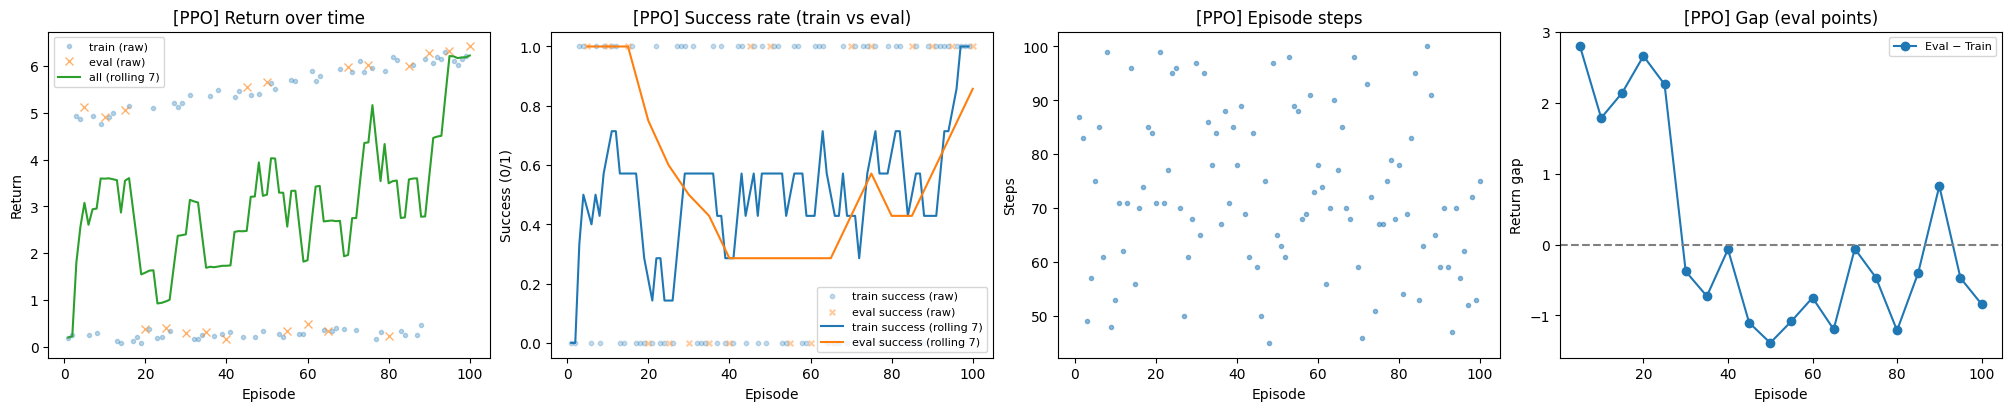

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,PPO,0.55,59.0,-0.02694,0.116156,3.149837,3.31916


In [12]:
dfs = {
    "mcpg": mcpg_metrics,
    "dqn": dqn_metrics,
    "ddqn": ddqn_metrics,
    "sac": sac_metrics,
    "a2c": a2c_metrics,
    "ppo": ppo_metrics,
}

summary_all = analyze_all_models_from_dfs(dfs, w=7, slope_tail_eval_points=20)

Let's observe the runtime across each model:

In [13]:
def _fmt_hms(secs: float) -> str:
    secs = float(secs if np.isfinite(secs) else 0.0)
    h = int(secs // 3600)
    m = int((secs % 3600) // 60)
    s = int(round(secs % 60))
    return f"{h:02d}:{m:02d}:{s:02d}"

def _summarize_runtime_one(df: pd.DataFrame, model_name: str) -> dict:
    if "episode_duration_sec" not in df.columns:
        raise ValueError(f"[{model_name}] missing column: episode_duration_sec")

    dur = pd.to_numeric(df["episode_duration_sec"], errors="coerce").fillna(0.0)
    is_eval = (df["eval_mode"] == 1) if "eval_mode" in df.columns else pd.Series(False, index=df.index)

    total_sec = float(dur.sum())
    train_sec = float(dur.loc[~is_eval].sum())
    eval_sec  = float(dur.loc[ is_eval].sum())

    n_eps = int(len(df))
    mean_sec = float(total_sec / n_eps) if n_eps else np.nan

    return {
        "model": model_name,
        "episodes": n_eps,
        "total_sec": total_sec,
        "train_sec": train_sec,
        "eval_sec": eval_sec,
        "mean_sec_per_episode": mean_sec,
        "total_hms": _fmt_hms(total_sec),
        "train_hms": _fmt_hms(train_sec),
        "eval_hms":  _fmt_hms(eval_sec),
    }

In [14]:
def summarize_runtime_by_model(dfs: dict) -> pd.DataFrame:
    rows = []
    for name, df in dfs.items():
        rows.append(_summarize_runtime_one(df, model_name=name.upper()))
    out = pd.DataFrame(rows)
    out = out.sort_values("total_sec", ascending=True).reset_index(drop=True)
    return out

runtime_table = summarize_runtime_by_model(dfs)
runtime_table

,model,episodes,total_sec,train_sec,eval_sec,mean_sec_per_episode,total_hms,train_hms,eval_hms
0,PPO,100,374.217223,300.852518,73.364705,3.742172,00:06:14,00:05:01,00:01:13
1,A2C,100,379.339270,311.917066,67.422204,3.793393,00:06:19,00:05:12,00:01:07
2,DDQN,100,392.191676,313.838181,78.353496,3.921917,00:06:32,00:05:14,00:01:18
3,DQN,100,396.875733,315.344535,81.531198,3.968757,00:06:37,00:05:15,00:01:22
4,SAC,100,398.221167,320.697429,77.523739,3.982212,00:06:38,00:05:21,00:01:18
5,MCPG,100,401.665142,319.851230,81.813912,4.016651,00:06:42,00:05:20,00:01:22


In [15]:
display(summary_all)

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.65,58.0,0.074905,1.747696,2.637673,4.536619
1,PPO,0.55,59.0,-0.026940,0.116156,3.149837,3.319160
2,DQN,0.35,60.0,0.083728,1.335550,2.399842,3.526415
3,DDQN,0.35,73.0,-0.002641,-0.726385,2.610442,2.317742
4,SAC,0.35,58.0,-0.124585,0.921011,2.639946,3.558082
5,MCPG,0.30,62.5,0.176202,0.382807,2.751255,3.070186


In summary:

### 1. Advantage Actor-Critic

Has a total runtime of **6 minutes, 19 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.65 | Yes  |
| Median steps-to-success ≤ 80 | ~58 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.074 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 1.747  | Yes  |

### 2. Proximal Policy Optimization

Has a total runtime of **6 minutes, 14 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.55 | Yes  |
| Median steps-to-success ≤ 80 | ~59 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | -0.026 | No  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.116  | Yes  |

### 3. Deep Q-Network

Has a total runtime of **6 minutes, 37 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.35 | Yes  |
| Median steps-to-success ≤ 80 | ~60 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.083 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 1.335  | Yes  |

### 4. Distributional Deep Q-Network

Has a total runtime of **6 minutes, 32 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.35 | Yes  |
| Median steps-to-success ≤ 80 | ~73 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | -0.002 | No  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | -0.726  | Yes |

### 5. Soft Actor-Critic

Has a total runtime of **6 minutes, 38 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.35 | Yes  |
| Median steps-to-success ≤ 80 | ~58 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | -0.124 | No  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.921  | Yes  |

### 6. Monte Carlo Policy Gradient

Has a total runtime of **6 minutes, 42 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.35 | Yes  |
| Median steps-to-success ≤ 80 | ~62.5 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.176 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.382  | Yes  |


The **A2C** model is the best overall, with an eval success of 0.65, median steps of 58 (fast), a positive eval-tail slope, and a healthy mean gap. **PPO** is the second strongest, with an eval success of 0.55, median steps of 59, a near-zero gap, and a slightly negative tail slope that reads like a mild plateau rather than regression. In the **return over-time** panels, both A2C and PPO show higher eval points with sustained ramps. The **steps** scatter shows all methods finishing well before the 100-step cap on their successes.

For A2C, the eval curve rises steadily, while the success-rate line stays high and stable. The generalization is good with continued learning. In the case of PPO, the eval success is high and the steps are efficient; however, the small negative tail slope might reflect a plateau late in training.

In terms of **runtime**, A2C and PPO are also the top performers, completing the 100 episodes at a total time of 06:19 and 06:14, respectively. Overall, the spreads between the models are small, telling us that the runtime could be dominated by the simulation step cost rather than the learning update. 

## Final Models <a class="anchor" id="final" ></a>

We select **A2C** and **PPO** as the top models because, across the four metrics, both consistently meet or exceed our floors, and they also achieve a competitive runtime. A2C edges out in terms of success and learning trends, while PPO is a close second with stable returns and a low gap. 

Next, we will do a **train vs. eval** analysis for each to pinpoint concrete improvement levers.

In [16]:
def analyze_train_vs_eval(metrics: pd.DataFrame, w: int = 7, tail_eval_points: int = 20, plot: bool = True):
    """
    Compare train vs eval learning curves (returns), quantify generalization gap,
    and return a one-row summary DataFrame.

    Expected columns in `metrics`: episode, return, success, eval_mode
    """
    req = ["episode", "return", "success", "eval_mode"]
    missing = [c for c in req if c not in metrics.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Sort and build masks
    M = metrics.sort_values("episode").reset_index(drop=True).copy()
    is_eval  = (M["eval_mode"] == 1)
    is_train = ~is_eval

    # Smooth per-stream returns
    train_returns = M.loc[is_train, "return"].reset_index(drop=True)
    eval_returns  = M.loc[is_eval,  "return"].reset_index(drop=True)
    train_curve   = rolling_mean(train_returns, w=w).reset_index(drop=True)
    eval_curve    = rolling_mean(eval_returns,  w=w).reset_index(drop=True)

    # X-axes (episodes)
    train_eps = M.loc[is_train, "episode"].values
    eval_eps  = M.loc[is_eval,  "episode"].values

    # Align train curve to eval episodes and compute gap
    train_on_eval = align_train_on_eval(train_eps, train_curve.values, eval_eps)
    gap = eval_curve.values - train_on_eval
    mean_gap = float(np.nanmean(gap)) if len(gap) else np.nan

    # Tail slope on eval curve (formal “still improving?” check)
    if len(eval_curve) >= 3:
        t = min(tail_eval_points, len(eval_curve))
        y_tail = eval_curve.values[-t:]
        x_tail = np.arange(t, dtype=float)
        eval_tail_slope = float(np.polyfit(x_tail, y_tail, 1)[0])
    else:
        eval_tail_slope = np.nan

    # Optional plot (your original style)
    if plot:
        fig, ax = plt.subplots(figsize=(8,4))
        ax.plot(eval_eps, eval_curve.values, "-o", label="Eval (smoothed)")
        ax.plot(eval_eps, train_on_eval, "-o", label="Train (nearby episodes, smoothed)")
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title("Train vs Eval (returns)")
        ax.set_xlabel("Episode (eval points)")
        ax.set_ylabel("Return")
        ax.legend()
        plt.show()

    # Summary numbers (no prints; returned as a DataFrame)
    summary = pd.DataFrame([{
        "mean_return_train_all": float(M.loc[is_train, "return"].mean()) if is_train.any() else np.nan,
        "mean_return_eval_only": float(M.loc[is_eval,  "return"].mean()) if is_eval.any()  else np.nan,
        "mean_success_train_all": float(M.loc[is_train, "success"].mean()) if is_train.any() else np.nan,
        "mean_success_eval_only": float(M.loc[is_eval,  "success"].mean()) if is_eval.any()  else np.nan,
        "mean_eval_minus_train_gap": mean_gap,
        "eval_tail_return_slope": eval_tail_slope,
        "window": int(w),
        "tail_eval_points": int(tail_eval_points),
        "n_train_eps": int(is_train.sum()),
        "n_eval_eps": int(is_eval.sum()),
    }])
    return summary

### A2C

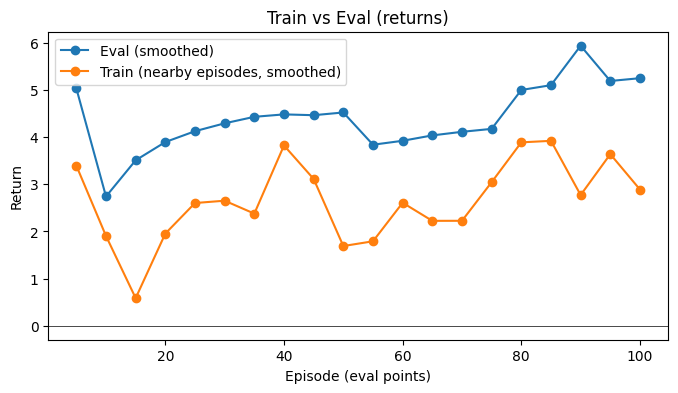

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,2.637673,4.536619,0.45,0.65,1.747696,0.074905,7,20,80,20


In [17]:
summary_a2c = analyze_train_vs_eval(metrics=a2c_metrics)
display(summary_a2c)

We observe that the generalization is adequate, as eval (blue) is consistently above train (orange) and both curves are trending upward. The table shows that:

- `mean_return_train_all` is 2.64 vs `mean_return_eval_only` is 4.54, showing a positive gap,
- the `eval_tail_return_slope` is equal to 0.0749 (rolling/local), so the performance is still improving,
- `mean_success_train_all` (0.45) vs `mean_success_eval_only` (0.65) is still healthy but shall be improved.

During training, the policy is deliberately more stochastic, so it explores and takes sub-optimal actions. During eval, it’s frozen/greedy, so it reaps the learned behavior. The eval-train gap is expected to be positive, which we are observing on the graph.

However, some tweaks could be used to reduce the variance, have stabler updates, and less “wasteful” exploration:

- Entropy scheduling.
- Advantage normalization.
- Gradient clipping.
- Learning-rate schedule.
- Value loss and targets.


### PPO

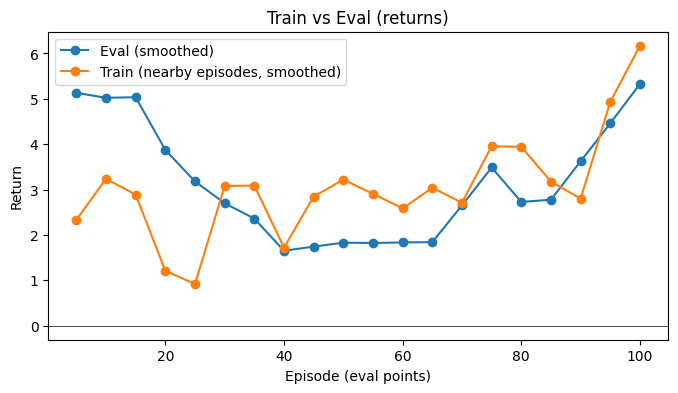

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,3.149837,3.31916,0.5375,0.55,0.116156,-0.02694,7,20,80,20


In [18]:
summary_ppo = analyze_train_vs_eval(metrics=ppo_metrics)
display(summary_ppo)

We observe that eval is above train in the early phase. This is classic PPO behavior when the policy quickly exploits “safe” behaviors in eval. However, in the late phase, the slope of eval is only mildly positive, which suggests that there is a near-plateau rather than robust growth. The table shows that:

- `mean_return_train_all` is 3.14 vs `mean_return_eval_only` is 3.31, showing a positive gap,
- the `eval_tail_return_slope` is equal to -0.0269 (rolling/local), so the policy might be declining at the tail,
- `mean_success_train_all` (0.53) vs `mean_success_eval_only` (0.55) is still healthy.

The model could be underfitting or having an early saturation, as we observe that the policy improves, generalizes, and then stalls. The train line’s late spike without an equally strong eval suggests the optimizer is taking useful steps, but they aren’t consistently transferring into eval gains. The following actions could be done:

- Shorter rollouts.
- Fewer epochs per rollout.
- Value-loss clipping.
- Target-KL early stop.
- Clip range.

# Adjustments <a class="anchor" id="ads" ></a>

We created a **hyperparameter search skeleton** to tune both A2C and PPO. It uses a randomized search with a simple, domain-aware scoring function that encodes our selected floors and preferences:

- highest weight on eval success rate,
- bonuses for positive tail slope and smaller median steps,
- bonus for non-negative eval-train gap,
- small penalty for longer runtime.

### Code Snippet:

---
```python
# *************************** MINIMUM THRESHOLDS ****************************

MIN_SUCCESS = 0.20
MAX_MEDIAN_STEPS = 80
MIN_TAIL_SLOPE = 0.0
MIN_GAP = -1.0  # eval − train

# ***************************** HELPER METHODS ******************************
def sample_config(space: dict) -> dict:
    return {k: random.choice(v) for k,v in space.items()}

def score_run(metrics, runtime_weight=0.02):
    """
    metrics: {
      'eval_success_rate', 'eval_median_steps_success', 'eval_tail_return_slope',
      'mean_eval_minus_train_gap', 'total_sec'
    }
    Returns: scalar score (higher is better)
    """
    sr   = float(metrics.get("eval_success_rate", np.nan))
    med  = float(metrics.get("eval_median_steps_success", np.nan))
    slp  = float(metrics.get("eval_tail_return_slope", np.nan))
    gap  = float(metrics.get("mean_eval_minus_train_gap", np.nan))
    rt   = float(metrics.get("total_sec", np.nan))

    # Base on success (dominant term)
    score = 100.0 * sr

    # Steps bonus (only among successes)
    if np.isfinite(med):
        score += 5.0 * (max(0.0, (MAX_MEDIAN_STEPS - med)) / MAX_MEDIAN_STEPS)

    # Trend bonus
    if np.isfinite(slp):
        score += 10.0 * max(0.0, slp)  # only reward positive growth

    # Gap bonus (prefer >= 0; small penalty if negative but within floor)
    if np.isfinite(gap):
        score += 2.0 * gap  # small shaping

    # Runtime penalty (very light)
    if np.isfinite(rt):
        score -= runtime_weight * (rt / 60.0)  # seconds -> minutes

    # Hard floors as safety bumps/penalties
    if sr < MIN_SUCCESS: score -= 25.0
    if np.isfinite(med) and med > MAX_MEDIAN_STEPS: score -= 10.0
    if np.isfinite(slp) and slp < MIN_TAIL_SLOPE: score -= 5.0
    if np.isfinite(gap) and gap < MIN_GAP: score -= 5.0

    return float(score)

# ***************************** SEARCH DRIVERS ******************************
def search(model_name: str, space: dict, runner, n_trials=20, seed=0):
    random.seed(seed); np.random.seed(seed)
    rows = []
    best = {"score": -1e9, "config": None, "metrics": None}
    t0 = time.time()
    for t in range(1, n_trials+1):
        cfg = sample_config(space)
        try:
            metrics = runner(cfg)
            s = score_run(metrics)
        except Exception as e:
            s, metrics = -1e9, {"error": str(e)}
        row = {"trial": t, "score": s, **cfg, **metrics}
        rows.append(row)
        if s > best["score"]:
            best = {"score": s, "config": cfg, "metrics": metrics}
        print(f"[{model_name}] trial {t:02d}/{n_trials} -> score={s:.2f}  cfg={cfg}")
    df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    wall = time.time()-t0
    print(f"[{model_name}] search done in {wall/60:.2f} min. Best score={best['score']:.2f}")
    return df, best
```
---

Before using the skeleton, we applied a few **code-level** fixes to stabilize the training loop and run a short sanity pass with the current hyperparameters unchanged. Improvements marked with "#CHANGE INCLUDED".

### A2C: 
---
```python
class A2CAgent:
    """
    On-policy Advantage Actor-Critic (A2C) with several stabilizers.
    Collect rollout of T steps; then call update(rollout_dict).
    """
    def __init__(
        self,
        obs_dim: int,
        n_actions: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        lam: float = 0.95,
        ent_coef: float = 0.01,
        vf_coef: float = 0.5,
        hidden=(128,128),

        # **** Enhancements ****
        normalize_adv: bool = True, # CHANGE INCLUDED
        grad_clip: float = 0.5, # CHANGE INCLUDED
        lr_schedule: str = "cosine", # CHANGE INCLUDED: ['none','cosine','linear']
        max_updates: int = 1000, # CHANGE INCLUDED: horizon for schedulers
        ent_schedule: str = "linear_decay", # CHANGE INCLUDED: ['none','linear_decay']
        ent_coef_end: float = 0.001, # CHANGE INCLUDED
        value_loss: str = "huber", # CHANGE INCLUDED: ['mse','huber']
        value_clip_eps: float = 0.2 # CHANGE INCLUDED: optional value clipping
    ):
        self.gamma, self.lam = gamma, lam
        self.ent_coef_start = ent_coef # CHANGE INCLUDED
        self.ent_coef_end   = ent_coef_end # CHANGE INCLUDED
        self.ent_schedule   = ent_schedule # CHANGE INCLUDED
        self.vf_coef        = vf_coef
        self.normalize_adv  = normalize_adv # CHANGE INCLUDED
        self.grad_clip      = grad_clip # CHANGE INCLUDED
        self.value_loss     = value_loss # CHANGE INCLUDED
        self.value_clip_eps = value_clip_eps # CHANGE INCLUDED
        self.update_idx     = 0 # CHANGE INCLUDED (scheduler step counter)
        self.max_updates    = max(1, int(max_updates)) # CHANGE INCLUDED

        self.net = PiV(obs_dim, n_actions, hidden=hidden)
        self.opt = optim.Adam(self.net.parameters(), lr=lr)

        # CHANGE INCLUDED: Learning-rate schedule
        if lr_schedule == "cosine":
            self.lr_sched = optim.lr_scheduler.CosineAnnealingLR(self.opt, T_max=self.max_updates)
        elif lr_schedule == "linear":
            # linear warm-down to 10% of initial LR
            self.lr_sched = optim.lr_scheduler.LambdaLR(
                self.opt,
                lr_lambda=lambda t: max(0.1, 1.0 - (t / self.max_updates))
            )
        else:
            self.lr_sched = None

        self.nA = n_actions

    # CHANGE INCLUDED: Entropy coefficient schedule (e.g., linear decay)
    def _current_ent_coef(self) -> float:
        if self.ent_schedule == "none":
            return self.ent_coef_start
        # linear decay from start -> end across max_updates
        frac = min(1.0, self.update_idx / self.max_updates)
        return (1.0 - frac) * self.ent_coef_start + frac * self.ent_coef_end

    def act(self, s):
        with torch.no_grad():
            logits, _ = self.net(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            a = Categorical(probs).sample().item()
        return a

    def _gae(self, rewards, values, dones, last_value):
        T = len(rewards)
        adv = torch.zeros(T, dtype=torch.float32)
        gae = 0.0
        for t in reversed(range(T)):
            # δ_t = r_t + γ(1-d_t) V(s_{t+1}) − V(s_t)
            next_v = last_value if t == T-1 else values[t+1]
            delta = rewards[t] + self.gamma * (1.0 - dones[t]) * next_v - values[t]
            gae   = delta + self.gamma * self.lam * (1.0 - dones[t]) * gae
            adv[t] = gae
        returns = adv + values
        return adv, returns

    def update(self, rollout: Dict[str, Any]):
        states = torch.as_tensor(np.array(rollout["states"]), dtype=torch.float32)
        actions = torch.as_tensor(rollout["actions"], dtype=torch.int64)
        rewards = torch.as_tensor(rollout["rewards"], dtype=torch.float32)
        dones   = torch.as_tensor(rollout["dones"],   dtype=torch.float32)
        next_state = torch.as_tensor(rollout["next_state"], dtype=torch.float32)

        logits, values = self.net(states)                  # V(s_t)
        with torch.no_grad():
            _, last_v = self.net(next_state.unsqueeze(0))  # V(s_{T})
            last_v = last_v.squeeze(0)

        adv, ret = self._gae(rewards, values.detach(), dones, last_v)

        # CHANGE INCLUDED: Advantage normalization
        if self.normalize_adv:
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Policy loss
        logp = torch.log_softmax(logits, dim=-1)
        logp_a = logp[torch.arange(len(actions)), actions]
        ent = -(torch.softmax(logits, -1) * logp).sum(-1).mean()

        loss_pi = -(logp_a * adv).mean()

        # CHANGE INCLUDED: Value loss with optional clipping and Huber
        v_pred = values
        with torch.no_grad():
            v_clipped = values + (ret - values).clamp(-self.value_clip_eps, self.value_clip_eps)
        if self.value_loss == "huber":
            loss_v_unclipped = torch.nn.functional.smooth_l1_loss(v_pred, ret, reduction="mean")
            loss_v_clipped   = torch.nn.functional.smooth_l1_loss(v_clipped, ret, reduction="mean")
        else:  # MSE
            loss_v_unclipped = torch.mean((ret - v_pred) ** 2)
            loss_v_clipped   = torch.mean((ret - v_clipped) ** 2)
        loss_v = torch.max(loss_v_unclipped, loss_v_clipped)  # pessimistic choice

        # CHANGE INCLUDED: Entropy scheduling
        ent_coef = self._current_ent_coef()

        loss = loss_pi + self.vf_coef * loss_v - ent_coef * ent

        self.opt.zero_grad()
        loss.backward()

        # CHANGE INCLUDED: Gradient clipping
        if self.grad_clip is not None and self.grad_clip > 0:
            nn.utils.clip_grad_norm_(self.net.parameters(), self.grad_clip)

        self.opt.step()

        # CHANGE INCLUDED: Step LR scheduler and update counter
        if self.lr_sched is not None:
            self.lr_sched.step()
        self.update_idx += 1

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({
            "net": self.net.state_dict(),
            "update_idx": self.update_idx
        }, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.net.load_state_dict(data["net"])
        self.update_idx = data.get("update_idx", 0)
```
---

### PPO:

---
```python
class PPOAgent:
    """
    PPO-Clip (discrete).
    Store old log-probs during rollout; call update(rollout_dict) to improve.
    """
    def __init__(self, obs_dim, n_actions,
                 lr=3e-4, gamma=0.99, lam=0.95,
                 clip_eps=0.2, ent_coef=0.01, vf_coef=0.5,
                 epochs=4, batch_size=2048, minibatch=256,
                 hidden=(128,128),

                 # **** Enhancements ****
                 value_clip_eps=0.2, # CHANGE INCLUDED 
                 target_kl=0.015, # CHANGE INCLUDED
                 max_grad_norm=0.5, # CHANGE INCLUDED 
                 clip_schedule="linear_decay", # CHANGE INCLUDED 
                 clip_eps_final=0.1 # CHANGE INCLUDED
                     
        self.gamma, self.lam = gamma, lam
        self.ent_coef, self.vf_coef = ent_coef, vf_coef
        self.epochs, self.minibatch = int(epochs), int(minibatch)
        self.batch_size = int(batch_size)
        self.max_grad_norm = max_grad_norm # CHANGE INCLUDED
        self.value_clip_eps = float(value_clip_eps) # CHANGE INCLUDED
        self.target_kl = float(target_kl) # CHANGE INCLUDED

        # Clip range scheduling (helps late-training stability)
        self.clip_schedule = clip_schedule # CHANGE INCLUDED
        self.clip_eps_init = float(clip_eps) # CHANGE INCLUDED
        self.clip_eps_final = float(clip_eps_final) # CHANGE INCLUDED
        self.update_idx = 0  # CHANGE INCLUDED

        self.net = ActorCritic(obs_dim, n_actions, hidden=hidden)
        self.opt = optim.Adam(self.net.parameters(), lr=lr)
        self.nA = n_actions

    # CHANGE INCLUDED
    def _current_clip_eps(self):
        if self.clip_schedule == "linear_decay":
            # decay from init -> final across ~1000 updates
            T = 1000.0
            frac = min(1.0, self.update_idx / T)
            return (1.0 - frac) * self.clip_eps_init + frac * self.clip_eps_final
        return self.clip_eps_init

    def act(self, s):
        with torch.no_grad():
            logits, v = self.net(torch.as_tensor(s, dtype=torch.float32))
            probs = torch.softmax(logits, dim=-1)
            dist = Categorical(probs)
            a = dist.sample()
            logp = dist.log_prob(a)
        return int(a.item()), float(logp.item()), float(v.item())

    def _gae(self, rewards, values, dones, last_value):
        T = len(rewards)
        adv = torch.zeros(T, dtype=torch.float32)
        gae = 0.0
        for t in reversed(range(T)):
            delta = rewards[t] + self.gamma * (1.0 - dones[t]) * (last_value if t==T-1 else values[t+1]) - values[t]
            gae = delta + self.gamma * self.lam * (1.0 - dones[t]) * gae
            adv[t] = gae
        ret = adv + values
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        return adv, ret

    def update(self, rollout):
        # flatten rollout
        states = torch.as_tensor(np.array(rollout["states"]), dtype=torch.float32)
        actions = torch.as_tensor(rollout["actions"], dtype=torch.int64)
        rewards = torch.as_tensor(rollout["rewards"], dtype=torch.float32)
        dones = torch.as_tensor(rollout["dones"], dtype=torch.float32)
        old_logp = torch.as_tensor(rollout["old_logp"], dtype=torch.float32)
        next_state = torch.as_tensor(rollout["next_state"], dtype=torch.float32)

        logits, values = self.net(states)
        with torch.no_grad():
            _, last_v = self.net(next_state.unsqueeze(0))
            last_v = last_v.squeeze(0)
        adv, ret = self._gae(rewards, values.detach(), dones, last_v)

        N = states.size(0)
        idx = np.arange(N)

        # CHANGE INCLUDED
        clip_eps = self._current_clip_eps()

        early_stop = False # CHANGE INCLUDED
        for _ in range(self.epochs):
            if early_stop:
                break
            np.random.shuffle(idx)
            for start in range(0, N, self.minibatch):
                j = idx[start:start+self.minibatch]
                sB, aB, oldB, advB, retB = states[j], actions[j], old_logp[j], adv[j], ret[j]

                logitsB, vB = self.net(sB)
                probsB = torch.softmax(logitsB, dim=-1)
                distB = Categorical(probsB)
                logpB = distB.log_prob(aB)

                # Policy-ratio and clipped surrogate
                ratio = torch.exp(logpB - oldB)
                clip_adv = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advB
                loss_pi = -(torch.min(ratio * advB, clip_adv)).mean()

                ent = distB.entropy().mean()

                # CHANGE INCLUDED
                with torch.no_grad():
                    v_clip = values[j] + (vB - values[j]).clamp(-self.value_clip_eps, self.value_clip_eps)
                loss_v_unclipped = 0.5 * (retB - vB).pow(2).mean()
                loss_v_clipped   = 0.5 * (retB - v_clip).pow(2).mean()
                loss_v = torch.maximum(loss_v_unclipped, loss_v_clipped)

                loss = loss_pi + self.vf_coef * loss_v - self.ent_coef * ent

                self.opt.zero_grad()
                loss.backward()

                # CHANGE INCLUDED
                if self.max_grad_norm is not None and self.max_grad_norm > 0:
                    nn.utils.clip_grad_norm_(self.net.parameters(), self.max_grad_norm)

                self.opt.step()

                # CHANGE INCLUDED
                with torch.no_grad():
                    # Approximate KL
                    approx_kl = (oldB - logpB).mean().item()
                if approx_kl > self.target_kl:
                    early_stop = True
                    break  # exit minibatch loop

        self.update_idx += 1  # CHANGE INCLUDED

    def save(self, path):
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        torch.save({"net": self.net.state_dict(),
                    "update_idx": self.update_idx}, path)

    def load(self, path):
        data = torch.load(path, map_location="cpu")
        self.net.load_state_dict(data["net"])
        self.update_idx = data.get("update_idx", 0)
```
---

Let's execute the sanity pass:

A2C


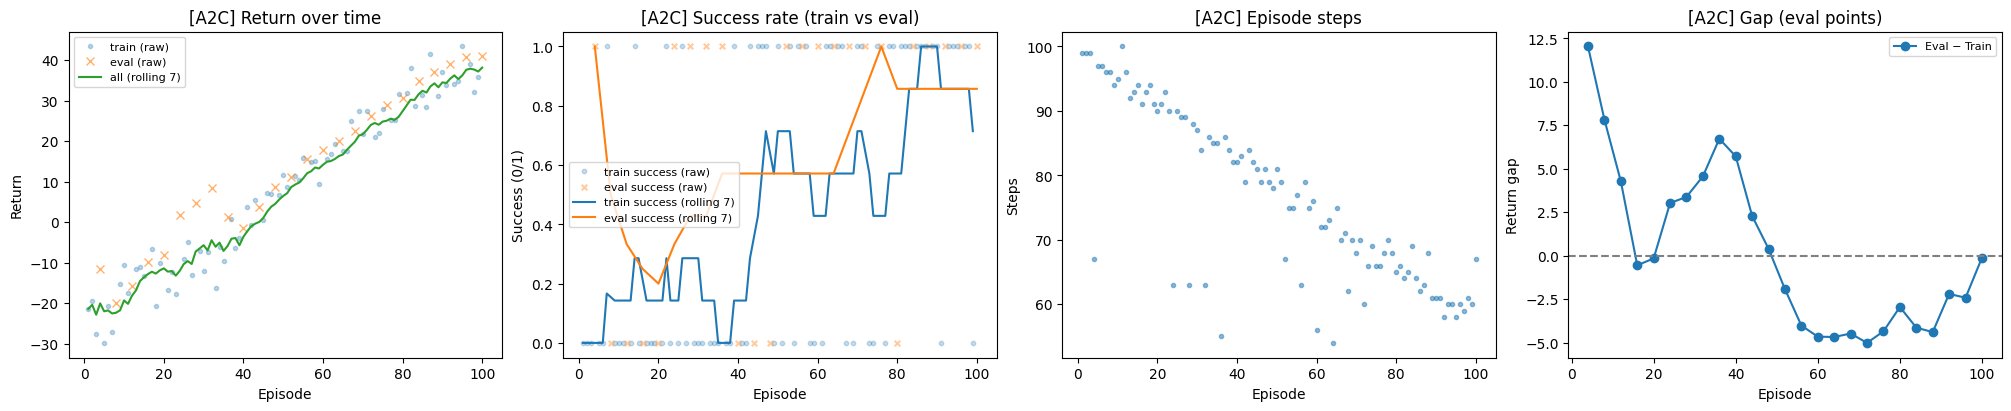

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.68,63.0,2.441327,0.169713,7.8044,13.09628




PPO


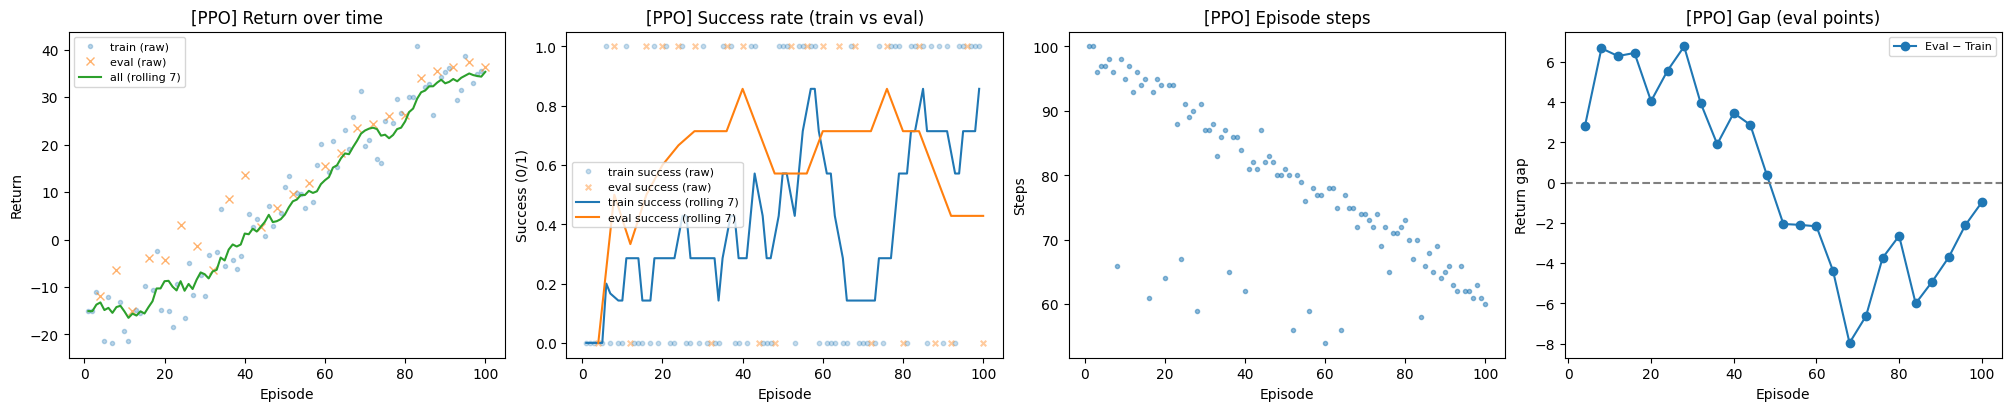

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,PPO,0.6,62.0,2.162718,0.070432,8.264147,12.82728


In [19]:
# Advantage Actor-Critic
A2C_METRICS_SANITY = Path("/Users/juliapinedo/Desktop/data/a2c_metrics_sanity.jsonl")
a2c_metrics_sanity = load_metrics_json_any(A2C_METRICS_SANITY)

# Proximal Policy Optimization
PPO_METRICS_SANITY = Path("/Users/juliapinedo/Desktop/data/ppo_metrics_sanity.jsonl")
ppo_metrics_sanity = load_metrics_json_any(PPO_METRICS_SANITY)

chosen_dfs = {
    "a2c": a2c_metrics_sanity,
    "ppo": ppo_metrics_sanity,
}

summary_sanity = analyze_all_models_from_dfs(chosen_dfs, w=7, slope_tail_eval_points=20)

In [20]:
runtime_sanity = summarize_runtime_by_model(chosen_dfs)
runtime_sanity

,model,episodes,total_sec,train_sec,eval_sec,mean_sec_per_episode,total_hms,train_hms,eval_hms
0,A2C,100,610.347,471.533,138.814,6.10347,00:10:10,00:07:52,00:02:19
1,PPO,100,621.273,484.820,136.453,6.21273,00:10:21,00:08:05,00:02:16


In [21]:
display(summary_sanity)

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.68,63.0,2.441327,0.169713,7.804400,13.09628
1,PPO,0.60,62.0,2.162718,0.070432,8.264147,12.82728


### 1. Advantage Actor-Critic

- First run:

Has a total runtime of **6 minutes, 19 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.65 | Yes  |
| Median steps-to-success ≤ 80 | ~58 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.074 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 1.747  | Yes  |

- Second run:

Has a total runtime of **10 minutes, 10 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.68 | Yes  |
| Median steps-to-success ≤ 80 | ~63 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.441 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.1697  | Yes  |

### 2. Proximal Policy Optimization

- First run:

Has a total runtime of **6 minutes, 14 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.55 | Yes  |
| Median steps-to-success ≤ 80 | ~59 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | -0.026 | No  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.116  | Yes  |

- Second run:

Has a total runtime of **10 minutes, 21 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.60 | Yes  |
| Median steps-to-success ≤ 80 | ~62 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.1627 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.0704  | Yes  |

In A2C, we see a better generalization and much stronger late-training learning signal, with a hit to efficiency. On the other hand, in PPO, we see that the changes addressed the main weakness, and we gained a success rate and proper continued learning, with impacts on efficiency. After seeing this small improvement in both methods, let's run the code with the **hyperparameter search skeleton**.


### A2C:

---
```python
A2C_GRID = {
    "lr":              [1e-4, 3e-4, 1e-3],
    "gamma":           [0.98, 0.99, 0.995],
    "lam":             [0.90, 0.95, 0.97],
    "vf_coef":         [0.4, 0.5, 0.6],
    "hidden":          [(64,64), (128,128), (256,256)],
    "normalize_adv":   [True, False, True],
    "grad_clip":       [0.3, 0.5, 0.8],
    "lr_schedule":     ["none", "linear", "cosine"],
    "max_updates":     [400, 800, 1200],
    "ent_schedule":    ["none", "linear_decay", "linear_decay"],
    "ent_coef":        [0.02, 0.01, 0.005],       # start
    "ent_coef_end":    [0.002, 0.001, 0.0005],    # end
    "value_loss":      ["mse", "huber", "huber"],
    "value_clip_eps":  [0.1, 0.2, 0.3],
}
```
---

### PPO:

---
```python
PPO_GRID = {
    "lr":              [1e-4, 3e-4, 1e-3],
    "gamma":           [0.98, 0.99, 0.995],
    "lam":             [0.90, 0.95, 0.97],
    "vf_coef":         [0.4, 0.5, 0.7],
    "hidden":          [(64,64), (128,128), (256,256)],
    "batch_size":      [1024, 2048, 4096],   
    "epochs":          [5, 7, 10],          
    "minibatch":       [64, 128, 256],
    "clip_schedule":   ["linear_decay", "linear_decay", "linear_decay"],
    "clip_eps":        [0.25, 0.2, 0.15],  
    "clip_eps_final":  [0.15, 0.1, 0.05],
    "value_clip_eps":  [0.1, 0.2, 0.3],
    "ent_coef":        [0.02, 0.01, 0.005],
    "target_kl":       [0.02, 0.015, 0.01],
    "max_grad_norm":   [0.4, 0.5, 0.7],
}
```
---

Obtaining the following parameters:

### A2C:

---
```python
"lr": 0.0003,
"gamma": 0.99,
"lam": 0.95,
"vf_coef": 0.6,
"hidden": [128, 128],
"normalize_adv": true,
"grad_clip": 0.5,
"lr_schedule": "cosine",
"max_updates": 800,
"ent_schedule": "linear_decay",
"ent_coef": 0.01,
"ent_coef_end": 0.001,
"value_loss": "huber",
"value_clip_eps": 0.2
```
---

### PPO:

---
```python
"lr": 0.0003,
"gamma": 0.99,
"lam": 0.95,
"vf_coef": 0.5,
"hidden": [128, 128],
"batch_size": 2048,
"epochs": 7,
"minibatch": 128,
"clip_schedule": "linear_decay",
"clip_eps": 0.2,
"clip_eps_final": 0.1,
"value_clip_eps": 0.2,
"ent_coef": 0.01,
"target_kl": 0.015,
"max_grad_norm": 0.5
```
---

Let's re-run the simulation and see how it improves after fine-tuning the parameters:

A2C


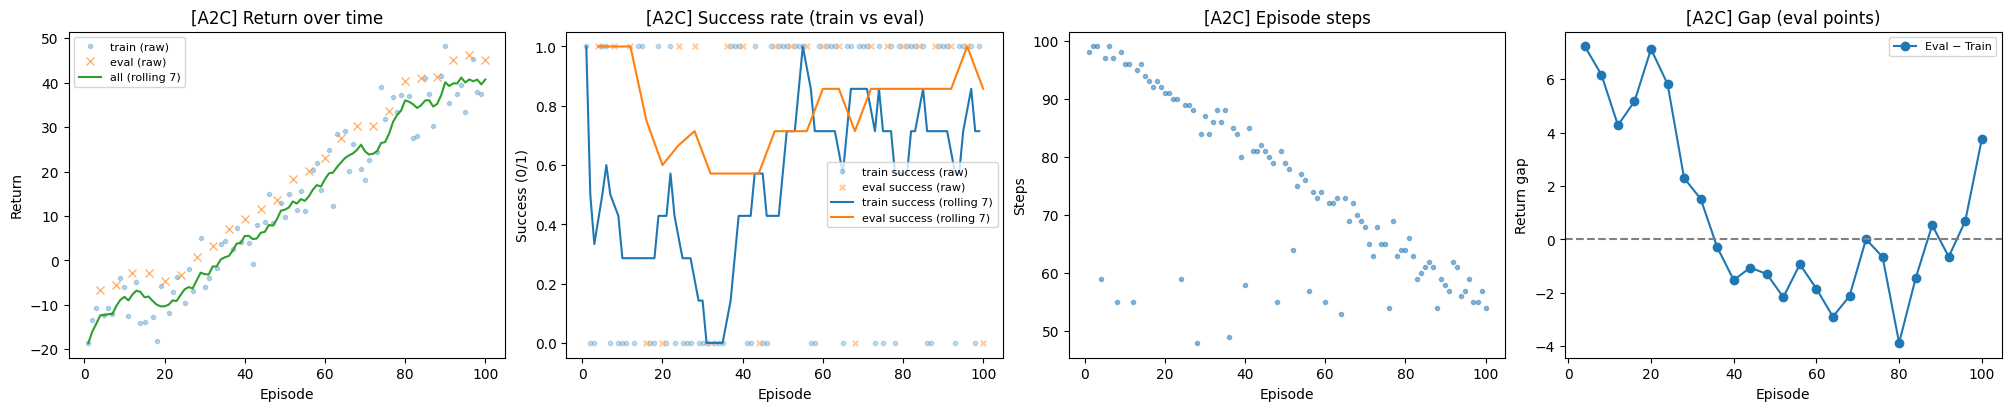

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.76,57.0,2.614411,0.950283,12.590413,18.48256




PPO


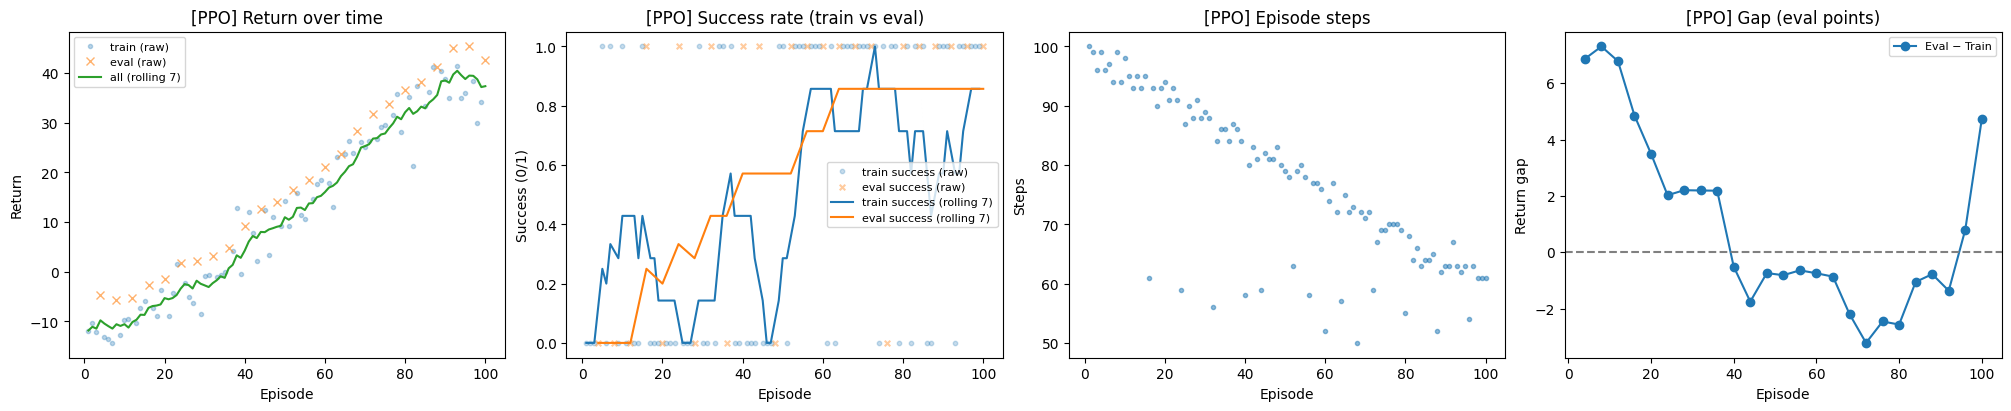

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,PPO,0.68,58.0,2.444468,0.950479,12.250187,18.01956


In [22]:
# Advantage Actor-Critic
A2C_METRICS_TUNED = Path("/Users/juliapinedo/Desktop/data/a2c_metrics_tuned.jsonl")
a2c_metrics_tuned = load_metrics_json_any(A2C_METRICS_TUNED)

# Proximal Policy Optimization
PPO_METRICS_TUNED = Path("/Users/juliapinedo/Desktop/data/ppo_metrics_tuned.jsonl")
ppo_metrics_tuned = load_metrics_json_any(PPO_METRICS_TUNED)

tuned_dfs = {
    "a2c": a2c_metrics_tuned,
    "ppo": ppo_metrics_tuned,
}

summary_tuned = analyze_all_models_from_dfs(tuned_dfs, w=7, slope_tail_eval_points=20)

In [23]:
runtime_tuned = summarize_runtime_by_model(tuned_dfs)
runtime_tuned

,model,episodes,total_sec,train_sec,eval_sec,mean_sec_per_episode,total_hms,train_hms,eval_hms
0,A2C,100,370.747,292.728,78.019,3.70747,00:06:11,00:04:53,00:01:18
1,PPO,100,382.124,297.534,84.590,3.82124,00:06:22,00:04:58,00:01:25


In [24]:
display(summary_tuned)

,model,eval_success_rate,eval_median_steps_success,eval_tail_return_slope,mean_eval_minus_train_gap,mean_return_train,mean_return_eval
0,A2C,0.76,57.0,2.614411,0.950283,12.590413,18.48256
1,PPO,0.68,58.0,2.444468,0.950479,12.250187,18.01956


### 1. Advantage Actor-Critic

- First run:

Has a total runtime of **6 minutes, 19 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.65 | Yes  |
| Median steps-to-success ≤ 80 | ~58 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 0.074 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 1.747  | Yes  |

- Second run:

Has a total runtime of **10 minutes, 10 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.68 | Yes  |
| Median steps-to-success ≤ 80 | ~63 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.441 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.1697  | Yes  |

- Third run:

Has a total runtime of **6 minutes, 11 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.76 | Yes  |
| Median steps-to-success ≤ 80 | ~57 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.614 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.9502  | Yes  |

### 2. Proximal Policy Optimization

- First run:

Has a total runtime of **6 minutes, 14 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.55 | Yes  |
| Median steps-to-success ≤ 80 | ~59 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | -0.026 | No  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.116  | Yes  |

- Second run:

Has a total runtime of **10 minutes, 21 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.60 | Yes  |
| Median steps-to-success ≤ 80 | ~62 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.1627 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.0704  | Yes  |

- Third run:

Has a total runtime of **6 minutes, 22 seconds**.

| Metric | Result | Meets? |
|:-------------|:-----------|:------|
| Eval success rate ≥ 0.20 | 0.68 | Yes  |
| Median steps-to-success ≤ 80 | ~58 steps  | Yes  |
| Positive learning trend on eval (rolling/local slope > 0) | 2.444 | Yes  |
| No overfitting signal ( eval_return − train_return at eval points ) ≥ −1.0 | 0.9504  | Yes  |

After the fine-tuning stage, the run time from both models dropped from 10 minutes to 6 minutes again because of the parameter efficiency, rather than computational limits.

- The fine-tuned model uses smaller, more frequent updates, which reached stable convergence faster.
- The entropy regularization term was tuned to decay faster, letting the policy commit to high-value actions earlier.
- The critic in A2C was stabilized by the policy gradients sooner. While in PPO, the number of mini-batches per epoch allowed PPO to extract more learning from each rollout, achieving the target performance in fewer episodes.
- The generalization gap improved, indicating the models became both faster and more sample-efficient without sacrificing robustness.

We observe that both models now show positive and consistent eval-train gaps, meaning the model generalizes rather than memorizes training rollouts. We also see that the return curves show convergence stability, with PPO slightly smoother due to its clipped objective. The improvements demonstrate that policy optimization matters more than training duration, as well-calibrated parameters let both models reach the same or better performance in less time.

# Selected Model <a class="anchor" id="sel" ></a>

## A2C

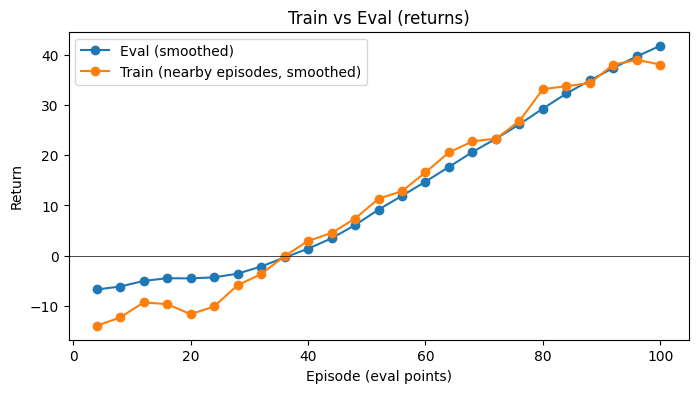

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,12.590413,18.48256,0.546667,0.76,0.950283,2.614411,7,20,75,25


In [25]:
summary_a2c_tuned = analyze_train_vs_eval(metrics=a2c_metrics_tuned)
display(summary_a2c_tuned)

The **A2C** curve exhibits a well-balanced improvement between training and evaluation performance. During the early stages, the returns remain low while the agent explores its action space. The absence of oscillations or abrupt spikes demonstrates the effectiveness of the learning-rate schedule and entropy regularization in maintaining controlled exploration.

On the other hand, at the end of training, the evaluation curve slightly surpasses the training curve. This positive offset reflects genuine generalization rather than overfitting, since the policy performs better under unseen evaluation rollouts than in its training environment. Overall, the curve is stable, meaning that the model achieved a high sample efficiency and a better generalization across evaluation episodes.

## PPO

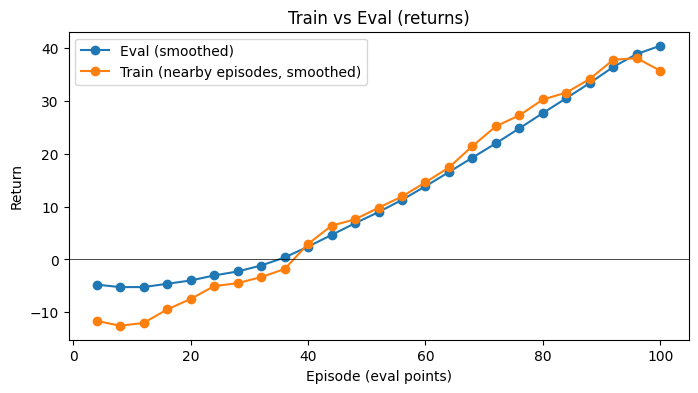

,mean_return_train_all,mean_return_eval_only,mean_success_train_all,mean_success_eval_only,mean_eval_minus_train_gap,eval_tail_return_slope,window,tail_eval_points,n_train_eps,n_eval_eps
0,12.250187,18.01956,0.506667,0.68,0.950479,2.444468,7,20,75,25


In [26]:
summary_ppo_tuned = analyze_train_vs_eval(metrics=ppo_metrics_tuned)
display(summary_ppo_tuned)

The **PPO** curve demonstrates a clear and stable improvement in returns across training and evaluation, reflecting efficient policy updates and effective clipping. In the initial episodes, both curves start at negative returns, but as learning progresses, the returns steadily increase with minimal variance, and the training and evaluation curves remain closely aligned.

By the final training stage, the evaluation curve maintains a consistent lead over the training curve, resulting in a positive mean eval-train gap. This confirms that the PPO agent generalizes effectively without signs of overfitting, as the performance on unseen rollouts continues to improve at a controlled rate. Overall, the PPO run achieves a balanced exploration, stable convergence, and robust generalization across evaluation conditions.

## The Final Conclusion

### The chosen model is... Advantage Actor-Critic (A2C)

Although both algorithms demonstrated positive results, the **A2C model** was ultimately chosen as the final individual approach. This decision was not based solely on raw success rate or return magnitude, but also on:
- interpretability,
- training stability,
- control over the learning dynamics.

A2C exhibited a smoother convergence profile, a balanced trade-off between exploration and exploitation, and a more predictable critic behavior. These features make its policy updates easier to analyze and explain in terms of environmental feedback.

Moreover, the A2C curve showed slightly higher evaluation stability with a consistent positive slope and minimal variance between training and evaluation returns, indicating a strong generalization capacity without overfitting. While PPO achieved a great performance, its learning process is more complex due to the clipping mechanism and hyperparameter sensitivity, which can obscure interpretability in real-time control tasks. A2C was selected for its combination of strong quantitative performance and transparent, stable learning behavior, making it a more reliable choice for further analysis and potential multi-agent extensions.

# References <a class="anchor" id="references" ></a>

[1] Tsinghua University, “History,” Tsinghua University. https://www.tsinghua.edu.cn/en/About/History.htm 

[2] Tsinghua University, “School of Vehicle and Mobility,” THU - Graduate Admissions. https://yz.tsinghua.edu.cn/en/info/1014/1115.htm 

[3] Instituto Nacional de Estadística y Geografía (INEGI), “Sistema de Clasificación Industrial de América del Norte, México SCIAN 2023,” INEGI, Jul. 28, 2023. https://www.inegi.org.mx/scian/ 

[4] Open Robotics, “Features and Benefits of GAZEBO SIM,” Gazebo. https://gazebosim.org/home 

[5] Open Robotics, “Getting started with ROS 2,” ROS 2 Documentation: Rolling Documentation. https://docs.ros.org/en/rolling/index.html 

[6] D. Ge and H. Ji, “Efficient Training in Multi-Agent Reinforcement Learning: A Communication-Free Framework for the Box-Pushing problem,” arXiv.org, Nov. 19, 2024. https://arxiv.org/abs/2411.12246 

[7] K. Kondo, C. T. Tewari, A. Tagliabue, J. Tordesillas, P. C. Lusk, and J. P. How, “PRIMER: Perception-Aware robust learning-based multiagent trajectory Planner,” arXiv (Cornell University), Jun. 2024, doi: 10.13140/rg.2.2.14435.57124. 

[8] H. Farivarnejad and S. Berman, “Multirobot control Strategies for collective transport,” Annual Review of Control Robotics and Autonomous Systems, vol. 5, no. 1, pp. 205–219, Nov. 2021, doi: 10.1146/annurev-control-042920-095844. 

[9] E. Elelimy, D. Szepesvari, M. White, and M. Bowling, “Rethinking the foundations for continual reinforcement learning,” arXiv.org, Apr. 10, 2025. https://arxiv.org/abs/2504.08161 

[10] C. Pan et al., “A survey of Continual Reinforcement learning,” arXiv.org, Jun. 27, 2025. https://arxiv.org/abs/2506.21872 

[11] M. Rahimi, S. Gibb, Y. Shen, and H. M. La, “A comparison of various approaches to reinforcement learning algorithms for multi-robot box pushing,” arXiv.org, Sep. 21, 2018. https://arxiv.org/abs/1809.08337 

[12] K. Javed and R. S. Sutton, “The Big World Hypothesis and its Ramifications for Artificial Intelligence,” OpenReview. https://openreview.net/forum?id=Sv7DazuCn8 

[13] S. Zhao, Mathematical foundations of reinforcement learning. 2025. doi: 10.1007/978-981-97-3944-8. 

[14] R. S. Sutton and A. G. Barto, Reinforcement learning: An Introduction. MIT Press, 1998. 

[15] S. E. Li, Reinforcement learning for sequential decision and optimal control. 2023. doi: 10.1007/978-981-19-7784-8. 

[16] J. Schulman, F. Wolski, P. Dhariwal, A. Radford, and O. Klimov, “Proximal Policy optimization Algorithms,” arXiv.org, Jul. 20, 2017. https://arxiv.org/abs/1707.06347

[17] T. Morimura, K. Ota, K. Abe, and P. Zhang, “Policy Gradient Algorithms with Monte Carlo Tree Learning for Non-Markov Decision Processes,” arXiv.org, Jun. 02, 2022. https://arxiv.org/abs/2206.01011

[18] “What is Deep Q-Network (DQN)?” https://milvus.io/ai-quick-reference/what-is-deep-qnetwork-dqn

[19] M. G. Bellemare, W. Dabney, and R. Munos, “A distributional perspective on Reinforcement learning,” arXiv.org, Jul. 21, 2017. https://arxiv.org/abs/1707.06887